**SIT720 - Machine Learning**

**8.1 DISTINCTION TASK (Machine Learning Mini Project)**

**SID: s225739657** , **Name: Jahan Ahmed**

# Sydney Housing Price Prediction and Decision Support System

**Project files:** [GitHub repository](https://github.com/Jahan-Geo/sydney-housing-price-estimator)

This project develops a housing price prediction and decision-support system for three Sydney suburbs: Surry Hills, Strathfield and Campbelltown. These suburbs represent inner, middle and outer parts of the Sydney market and have different dwelling mixes and price levels. The dataset contains 180 manually collected sold-property records from realestate.com.au, with 60 properties from each suburb. The dataset covers about 11 months of sales, which is enough for a small modelling exercise but not for long-term market analysis.

The data check showed several limitations. `year_built`, `listing_description` and `source_url` were missing for every property. Land size, floor area and car spaces also had substantial missing values. Three Campbelltown addresses were recorded as houses even though their address format suggested units, so these were corrected after checking them. CB029 was also unusual, with 16 bedrooms and 9 bathrooms. It was excluded from the main modelling because it was not representative of the other properties, while the results were also checked with and without it. After this, 179 properties remained for modelling. The main limitation is that the sample is small and covers only three suburbs and a short time period.

## Part 1: Problem Definition and Data Collection

**Suburbs selected:** Surry Hills (Inner), Strathfield (Middle), Campbelltown (Outer)

The following sections document the data collection, data-quality checks, missing values, price patterns, possible bias and limitations before modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams.update({'font.size': 11})

SUBURBS = ['Surry Hills', 'Strathfield', 'Campbelltown']
COLORS = {'Surry Hills': '#2E86AB', 'Strathfield': '#A23B72', 'Campbelltown': '#F18F01'}


## 1.1 Load the raw collected data

Data was manually collected from **Realestate.com.au** using "Sold" listings from the last approximately 12 months. The data was entered into the provided Excel template. Row 1 contains the column headers, Row 2 provides column-level guidance on data types and formats, and Row 3 contains a worked example. The actual collected data starts from Row 4, so Rows 2 and 3 were skipped when loading the dataset.


In [2]:
FILE = "Sydney_Housing_Data_Collection_Template (3).xlsx" # same folder as this notebook

df = pd.read_excel(FILE, sheet_name="Data", header=0, skiprows=[1, 2])
df.columns = [
 'property_id','suburb','suburb_ring','address_street','sale_price','sale_date',
 'property_type','bedrooms','bathrooms','car_spaces','land_size_sqm','floor_area_sqm',
 'distance_to_cbd_km','year_built','listing_description','notes_anomaly','source_url'
]
df.columns = df.columns.str.strip() # defensive: guarantees clean column names even if the source Excel ever has stray whitespace in headers
df = df.dropna(how='all').reset_index(drop=True)
df['sale_date'] = pd.to_datetime(df['sale_date'], format='%d/%m/%Y', errors='coerce')

print(f"Rows loaded: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(5)
# Check that all three selected suburbs are present in the loaded data.
_missing_suburbs = [s for s in SUBURBS if s not in df['suburb'].unique()]
assert not _missing_suburbs, f"SUBURBS contains names not present in df['suburb']: {_missing_suburbs}"
print("SUBURBS/data consistency check passed:", SUBURBS)

df.head(5)

Rows loaded: 180, Columns: 17
SUBURBS/data consistency check passed: ['Surry Hills', 'Strathfield', 'Campbelltown']


,property_id,suburb,suburb_ring,address_street,sale_price,sale_date,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,floor_area_sqm,distance_to_cbd_km,year_built,listing_description,notes_anomaly,source_url
0,SH001,Surry Hills,Inner,107/117 Kippax Street,750000,2026-08-12,Unit,1,1.0,NaN,NaN,48.0,2.5,NaN,NaN,Original type label: Studio,NaN
1,SH002,Surry Hills,Inner,57/1-7 Pelican Street,710000,2026-08-04,Unit,1,1.0,NaN,NaN,60.0,2.5,NaN,NaN,Original type label: Apartment,NaN
2,SH003,Surry Hills,Inner,4/329-333 Crown Street,1300000,2026-07-23,Unit,2,1.0,1.0,NaN,104.0,2.5,NaN,NaN,Original type label: Apartment,NaN
3,SH004,Surry Hills,Inner,17/6 Poplar Street,740000,2026-07-17,Unit,1,1.0,NaN,NaN,73.0,2.5,NaN,NaN,Original type label: Apartment,NaN
4,SH005,Surry Hills,Inner,53 Marshall Street,2310000,2026-06-27,House,2,1.0,NaN,68.0,NaN,2.5,NaN,NaN,Original type label: House,NaN


## 1.2 Sample size check per suburb

The brief requires **>=100 properties total, >=30 per suburb**.

In [3]:
counts = df['suburb'].value_counts().reindex(SUBURBS)
print(counts)
print(f"\nTotal properties: {counts.sum()}")
assert counts.min() >= 30, "A suburb has fewer than 30 rows"
assert counts.sum() >= 100, "Total dataset has fewer than 100 rows"
print("\nSample size requirement satisfied (60 per suburb, 180 total).")

suburb
Surry Hills     60
Strathfield     60
Campbelltown    60
Name: count, dtype: int64

Total properties: 180

Sample size requirement satisfied (60 per suburb, 180 total).


## 1.3 Data checks: duplicates, IDs, and suburb information

In [4]:
print("Duplicate property_id:", df['property_id'].duplicated().sum())
print("Duplicate full address+suburb:", df.duplicated(subset=['suburb','address_street','sale_price','sale_date']).sum())

# suburb_ring and distance_to_cbd_km should be constant within each suburb (auto-filled by template formula)
print("\nsuburb_ring by suburb:")
print(df.groupby('suburb')['suburb_ring'].unique())
print("\ndistance_to_cbd_km by suburb:")
print(df.groupby('suburb')['distance_to_cbd_km'].unique())

Duplicate property_id: 0
Duplicate full address+suburb: 0

suburb_ring by suburb:
suburb
Campbelltown     [Outer]
Strathfield     [Middle]
Surry Hills      [Inner]
Name: suburb_ring, dtype: object

distance_to_cbd_km by suburb:
suburb
Campbelltown    [54.0]
Strathfield     [14.0]
Surry Hills      [2.5]
Name: distance_to_cbd_km, dtype: object


### 1.3b Checking property type using the address

Unit-style addresses (e.g., 12/34 Smith Street) should not be labelled as House. This was checked directly using the address_street field, separately from the bedroom/bathroom-based structural check in Section 1.8. The check was performed immediately after the structural checks in Section 1.3 and before calculating any statistics that depend on property_type. Therefore, any corrections were reflected in the subsequent analysis.


In [5]:
# Any address with a leading "<number>/<number>..." unit prefix should not be a House.
unit_prefix_mismatch = df[
 df['address_street'].str.contains(r'^\d+/', regex=True, na=False) & (df['property_type'] == 'House')
][['property_id', 'suburb', 'address_street', 'property_type', 'bedrooms', 'sale_price']]

print(f"Rows with a unit-style address prefix but labelled 'House': {len(unit_prefix_mismatch)}")
display(unit_prefix_mismatch)

# Relabel these three Campbelltown records as units.
# Their addresses, bedroom counts and sale prices are more consistent with units
# than houses (see Section 2.2).
mismatch_ids = unit_prefix_mismatch['property_id'].tolist()
df.loc[df['property_id'].isin(mismatch_ids), 'property_type'] = 'Unit'

# Run the check again after the correction.
remaining_mismatch = df[
 df['address_street'].str.contains(r'^\d+/', regex=True, na=False) & (df['property_type'] == 'House')
]
print(f"Corrected {len(mismatch_ids)} rows to 'Unit': {mismatch_ids}")
print(f"Remaining mismatches after correction: {len(remaining_mismatch)}")


Rows with a unit-style address prefix but labelled 'House': 3


,property_id,suburb,address_street,property_type,bedrooms,sale_price
144,CB025,Campbelltown,122/3-17 Queen street,House,2,575000
152,CB033,Campbelltown,201/30-34 Chamberlain Street,House,2,610000
155,CB036,Campbelltown,11/3-9 Warby Street,House,1,430000


Corrected 3 rows to 'Unit': ['CB025', 'CB033', 'CB036']
Remaining mismatches after correction: 0


Three records (`CB025`, `CB033`, `CB036`) were found to have unit-style address prefixes but were recorded as `House`. Because this inconsistency could be verified directly from the address field, the records were relabelled as Unit before any statistics or models were computed, so all later results use the corrected classification.

`CB029` was treated differently and excluded from the modelling dataset. Its combination of 16 bedrooms, 9 bathrooms, and a 797 sqm block could not be plausibly reconciled with a single-dwelling category. In contrast, the three records with unit-style addresses had clear evidence supporting the `Unit` classification. Therefore, relabelling was considered more appropriate than excluding these records.


## 1.4 Checking missing data

The template instructs leaving a cell blank (not `0`/`N/A`) when genuinely unknown, so missingness here reflects real information gaps in the source listings, not data-entry laziness.

In [6]:
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_tbl = missing_pct[missing_pct > 0].to_frame('% missing')
missing_tbl

,% missing
source_url,100.0
listing_description,100.0
year_built,100.0
floor_area_sqm,54.4
land_size_sqm,45.6
car_spaces,22.8
bathrooms,1.1


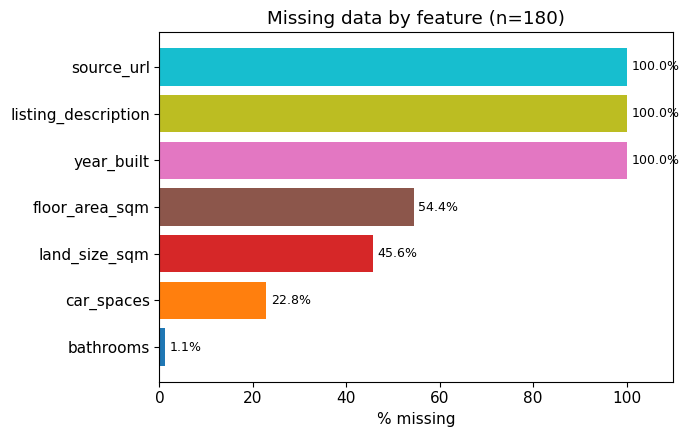

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
m = missing_pct[missing_pct > 0].sort_values()

# Assign a unique color from tab10 colormap for each bar
colors = plt.cm.tab10(np.linspace(0, 1, len(m)))
ax.barh(m.index, m.values, color=colors)

# Add percentage labels with one decimal
for i, v in enumerate(m.values):
 ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, 110)
ax.set_xlabel('% missing')
ax.set_title(f'Missing data by feature (n={len(df)})')
plt.tight_layout()
plt.show()

**Reading the missingness:**

* `year_built`, `listing_description`, and `source_url` had **100% missing values**. The reasons for these missing values could not be verified from the collected data; they were simply left blank as genuinely unknown. The absence of `year_built` is also important because property age can influence prices, for example, through differences between renovated and original-condition properties. This limitation is considered again in Part 4 when discussing the model's largest prediction errors.

* `floor_area_sqm` (54.4%) and `land_size_sqm` (45.6%) had substantial missing values. This was partly related to property type. Units and apartments may not have a separate land size, while floor area is not always reported for houses. Therefore, these values cannot simply be assumed to be missing at random and require suburb- and property-type-based imputation in the modelling pipeline (Section 3.1).

* `car_spaces` had **22.8% missing values**. Some inner-city unit listings do not report parking, particularly when no parking is available. Therefore, the missing values may contain useful information rather than being completely random.

* `bathrooms` had only **1.1% missing values**, representing a small number of isolated omissions.

* The 100% missing `source_url` also means that none of the 180 listings can be independently traced back to their original source page. This limits the auditability of the dataset because individual sales cannot be checked against the original listing. The accuracy of the data therefore depends on the manual collection process. Recording `source_url` in any future data collection would improve the reproducibility and verification of the dataset.


### 1.4b Missingness by Property Type

To check whether `land_size_sqm` and `floor_area_sqm` are missing because of property type rather than at random, missingness is cross-tabulated by property type below.


In [8]:
missingness_by_type = df.groupby('property_type')[['land_size_sqm', 'floor_area_sqm', 'car_spaces']].apply(
 lambda g: g.isna().mean() * 100
).round(1)
missingness_by_type.columns = ['% land_size missing', '% floor_area missing', '% car_spaces missing']
missingness_by_type


,% land_size missing,% floor_area missing,% car_spaces missing
property_type,,,
House,0.0,100.0,17.9
Semi/Terrace,100.0,0.0,25.0
Townhouse,100.0,0.0,0.0
Unit,96.2,3.8,29.5


The cross-tabulation of missingness by property type shows that `land_size_sqm` is missing for nearly all `Unit` records, which is expected because land size generally does not apply to units. In contrast, it is rarely missing for `House` records. `floor_area_sqm` shows the opposite pattern, with missing values concentrated among houses. These patterns indicate that missingness is related to dwelling type rather than being random. Therefore, the `HousingFeatureEngineer` transformer (Section 3.1) imputes these two fields using property-type-specific group medians instead of a single dataset-wide median, which could misrepresent the characteristics of the two dwelling types.

## 1.5 Property type mix by suburb

The collection brief deliberately allowed the property-type mix to reflect each suburb's *real* market composition rather than forcing an even split.

In [9]:
type_counts = pd.crosstab(df['suburb'], df['property_type']).reindex(SUBURBS)
type_pct = (type_counts.div(type_counts.sum(axis=1), axis=0) * 100).round(1)
display(type_counts)
display(type_pct)

property_type,House,Semi/Terrace,Townhouse,Unit
suburb,,,,
Surry Hills,18,2,0,40
Strathfield,37,1,1,21
Campbelltown,40,1,2,17


property_type,House,Semi/Terrace,Townhouse,Unit
suburb,,,,
Surry Hills,30.0,3.3,0.0,66.7
Strathfield,61.7,1.7,1.7,35.0
Campbelltown,66.7,1.7,3.3,28.3


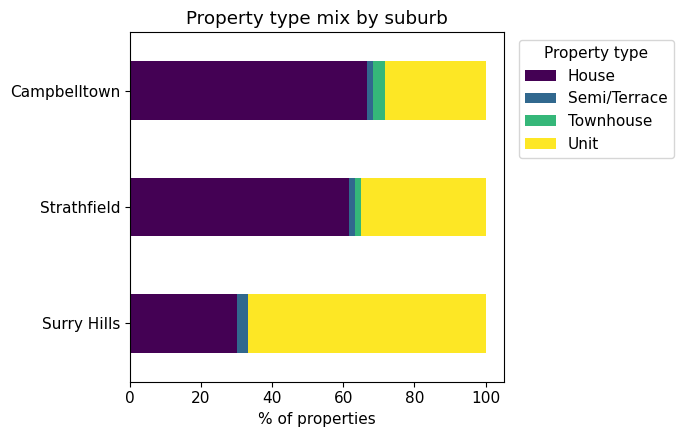

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
type_pct.plot(kind='barh', stacked=True, ax=ax, colormap='viridis')
ax.set_xlabel('% of properties'); ax.set_ylabel('')
ax.set_title('Property type mix by suburb')
ax.legend(title='Property type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Surry Hills is mainly unit-dominated (about 67%), while Campbelltown is mainly house-dominated (about 67% also, after the Section 1.3b correction of three mislabelled unit-style addresses). Strathfield has a more balanced mix, with a higher proportion of high-value houses as well as units. This reflects differences in the housing stock across the three suburbs. Therefore, price comparisons between suburbs should also consider dwelling type.

## 1.6 Sale price distribution by suburb (the prediction target)

In [11]:
price_summary = df.groupby('suburb')['sale_price'].describe()[['count','mean','50%','min','max','std']]
price_summary.columns = ['count','mean','median','min','max','std']
price_summary.reindex(SUBURBS).round(0)

,count,mean,median,min,max,std
suburb,,,,,,
Surry Hills,60.0,1577812.0,1330000.0,308000.0,5000000.0,953052.0
Strathfield,60.0,3477796.0,3367500.0,520000.0,12050000.0,2718438.0
Campbelltown,60.0,938442.0,927500.0,430000.0,1670000.0,298548.0


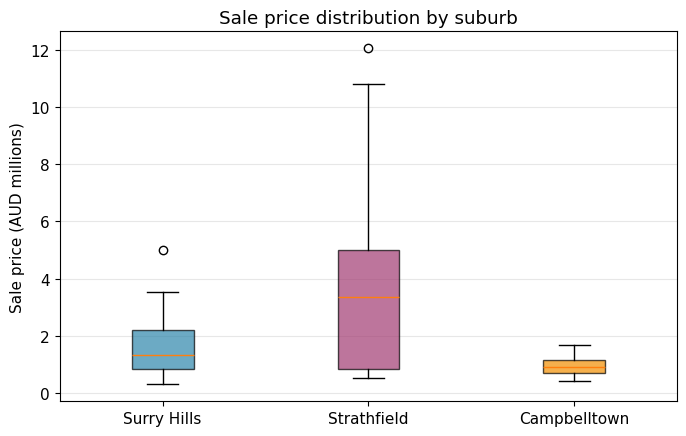

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [df[df.suburb == s]['sale_price'] / 1e6 for s in SUBURBS]
bp = ax.boxplot(data, tick_labels=SUBURBS, patch_artist=True)
for patch, s in zip(bp['boxes'], SUBURBS):
 patch.set_facecolor(COLORS[s]); patch.set_alpha(0.7)
ax.set_ylabel('Sale price (AUD millions)')
ax.set_title('Sale price distribution by suburb')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

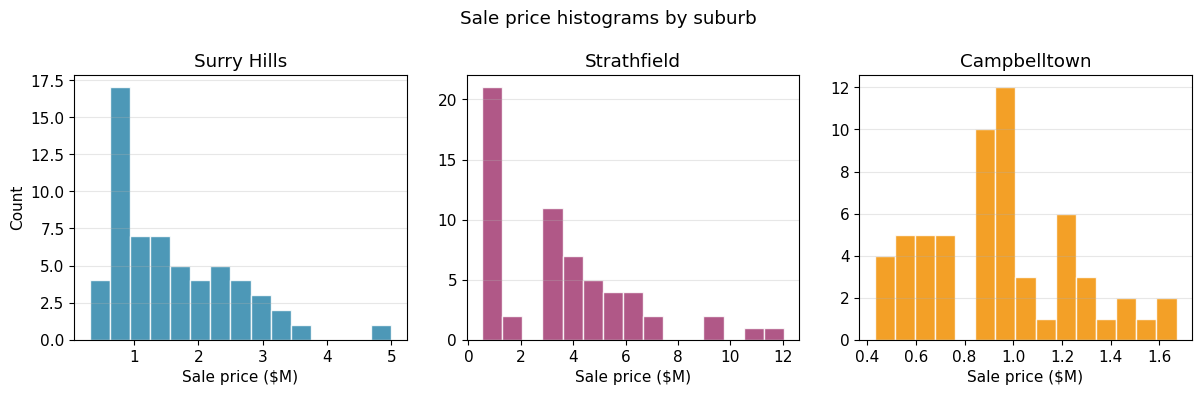

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for ax, s in zip(axes, SUBURBS):
 sub = df[df.suburb == s]['sale_price'] / 1e6
 ax.hist(sub, bins=15, color=COLORS[s], alpha=0.85, edgecolor='white')
 ax.set_title(s); ax.set_xlabel('Sale price ($M)')
 ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Count')
plt.suptitle('Sale price histograms by suburb')
plt.tight_layout()
plt.show()

Median sale prices differ by approximately **3.6×** across the three suburbs, ranging from around **\$0.93M** in Campbelltown to **\$3.37M** in Strathfield. Strathfield is also strongly right-skewed because of a small number of multi-million-dollar sales, with the highest sale reaching approximately **\$12.05M**. This suggests that the three suburbs represent different parts of the Sydney housing market. The wide price range also supports using a log transformation of sale price, as it can reduce the effect of extreme values and improve model performance.

## 1.7 Sale dates in the dataset

In [14]:
date_summary = df.groupby('suburb')['sale_date'].agg(['min','max','count'])
date_summary.reindex(SUBURBS)

,min,max,count
suburb,,,
Surry Hills,2025-09-27,2026-08-12,60
Strathfield,2025-12-02,2026-08-14,60
Campbelltown,2025-09-24,2026-08-10,60


The sales data covers approximately **11 months, from September 2025 to August 2026**. This period was practical for manual data collection but remains relatively short. As a result, the dataset does not capture **longer-term market trends or seasonal variations**. This limitation should be considered when interpreting the model results.

## 1.8 Checking unusual values and possible data-entry errors

Before modelling, I checked for values that looked unusual or possibly incorrect so they would not be included without review.

In [15]:
# Flag rows with unusually high bedroom counts (possible data-entry error
# or a boarding-house / multi-dwelling sale that doesn't behave like a typical single dwelling)
suspect = df[(df['bedrooms'] >= 8)]
suspect[['property_id','suburb','address_street','property_type','bedrooms','bathrooms',
 'land_size_sqm','sale_price','notes_anomaly']]

,property_id,suburb,address_street,property_type,bedrooms,bathrooms,land_size_sqm,sale_price,notes_anomaly
148,CB029,Campbelltown,17 Genty street,House,16,9.0,797.0,1525000,Original type label: House


**CB029** (17 Genty Street, Campbelltown) is recorded with **16 bedrooms and 9 bathrooms** on a 797 sqm block, with a sale price of **$1.525M**. These characteristics are unusual for a typical single-family house and differ substantially from the suburb's house median. This may be due to a **data-entry or parsing error**, although the property could also be a boarding house or multi-unit property. It was retained in the dataset but flagged for **further investigation and possible exclusion** during Part 2 and Part 4 modelling.

## 1.9 Checking the `notes_anomaly` column

The template intended the `notes_anomaly` column to record genuine sale anomalies, such as **deceased estates, off-market sales, renovations, or flood-affected properties**. However, in this dataset, the column was used to record the **original property-type label** from the source listing, such as *"Studio"*, *"Apartment"*, or *"Duplex/semi-detached"*. These labels were then standardised into the four-category `property_type` field.

In [16]:
df['notes_anomaly'].value_counts()

notes_anomaly
Original type label: House                   98
Original type label: Apartment               61
Original type label: Unit                     8
Original type label: Studio                   5
Original type label: Duplex/semi-detached     3
Original type label: Townhouse                3
Original type label: Terrace                  1
Original type label: Villa                    1
Name: count, dtype: int64

This information is still useful because it shows how the original source labels were grouped into the standard categories. However, the dataset currently has **no explicit flag for genuine sale anomalies**. This should be treated as a limitation and addressed either by **re-reviewing the original listings** or by using **extreme price residuals in Part 4 as a proxy for anomaly detection**.

## 1.10 Correlation between numeric features and price

A first look only -- not a substitute for the full modelling in later parts.

In [17]:
numeric_cols = ['sale_price','bedrooms','bathrooms','car_spaces','land_size_sqm','floor_area_sqm']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce') # defensive: guarantees these are numeric dtype before corr()
corr = df[numeric_cols].corr(numeric_only=True)['sale_price'].drop('sale_price').sort_values(ascending=False)
corr.round(2)

car_spaces        0.78
bathrooms         0.65
bedrooms          0.50
land_size_sqm     0.47
floor_area_sqm    0.36
Name: sale_price, dtype: float64

## 1.11 Summary of Part 1 Data Findings

* **180 sold properties** were collected, with 60 properties from each suburb: Surry Hills, Strathfield, and Campbelltown. This meets the requirement of at least 100 properties overall and 30 properties per suburb.

* The three suburbs differ in **distance from the CBD** (2.5, 14, and 54 km), **suburb ring** (Inner, Middle, and Outer), **dwelling mix**, and **median sale price** (approximately **\$1.33M**, **\$3.37M**, and **\$0.93M**, respectively).

* Missing data is concentrated in `year_built`, `listing_description`, and `source_url`, which are **100% missing**. Structured missing values are also present in `land_size_sqm`, `floor_area_sqm`, and `car_spaces`.

* The **property-type mix** reflects the actual characteristics of each suburb rather than being artificially balanced.

* **CB029** was identified as a potential data-entry or property-type outlier. The use of the `notes_anomaly` field was also identified as an issue and flagged for further investigation.

* Sale dates cover approximately **11 months**, which limits the ability to examine longer-term market trends and cycles.


## 1.12 Possible bias in the collected sample

I also considered two possible sources of bias in the collected sample:

* **Temporal bias:** Strathfield sales begin in December 2025, while Surry Hills and Campbelltown begin in September 2025. Changes in the market during this period may affect Strathfield's price statistics.

* **Portal selection bias:** The dataset only includes publicly advertised sold listings from realestate.com.au. Off-market sales and sales with undisclosed prices are excluded, so the sample may not fully represent the actual market.

These limitations may affect the **generalisability** of the findings but cannot be fully addressed using the current collection method.



# Part 2: Data Understanding and Feature Engineering

This part examines the dataset before modelling, focusing on **price distribution, differences between suburbs, trends over time, and unusual observations**. These findings are then used to identify the **three features expected to have the greatest influence on sale price** before developing the final feature set for Part 3.


## 2.1 Sale price distribution and log transformation

In [18]:
from scipy import stats as sstats

skew_raw = sstats.skew(df['sale_price'])
kurt_raw = sstats.kurtosis(df['sale_price'])
log_price = np.log(df['sale_price'])
skew_log = sstats.skew(log_price)
kurt_log = sstats.kurtosis(log_price)

print(f"Raw sale_price -> skew: {skew_raw:.2f}, excess kurtosis: {kurt_raw:.2f}")
print(f"log(sale_price) -> skew: {skew_log:.2f}, excess kurtosis: {kurt_log:.2f}")

Raw sale_price -> skew: 2.30, excess kurtosis: 6.23
log(sale_price) -> skew: 0.65, excess kurtosis: -0.45


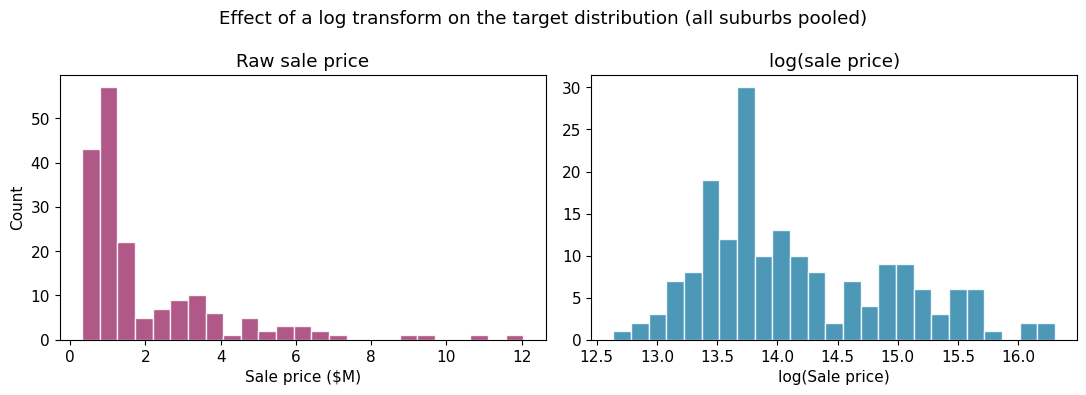

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['sale_price'] / 1e6, bins=25, color=COLORS['Strathfield'], alpha=0.85, edgecolor='white')
axes[0].set_title('Raw sale price'); axes[0].set_xlabel('Sale price ($M)'); axes[0].set_ylabel('Count')
axes[1].hist(np.log(df['sale_price']), bins=25, color=COLORS['Surry Hills'], alpha=0.85, edgecolor='white')
axes[1].set_title('log(sale price)'); axes[1].set_xlabel('log(Sale price)')
plt.suptitle('Effect of a log transform on the target distribution (all suburbs pooled)')
plt.tight_layout()
plt.show()

Across all three suburbs, raw `sale_price` is **strongly right-skewed**, mainly because of a small number of high-value Strathfield properties, with prices reaching above **$12M**. Applying a log transformation reduces the **skewness and kurtosis**, resulting in a more balanced distribution. This reduces the influence of extreme values during modelling. Therefore, `log(sale_price)` is used as the **modelling target**, with predictions converted back to dollar values for reporting.

## 2.2 Differences between suburbs

We previously found in **Part 1, Section 1.6** that median sale prices differ by approximately **3.6×** across the three suburbs. This section examines the difference in greater detail by testing whether it is **statistically significant** and whether the pattern remains after **controlling for property type**.

In [20]:
# One-way ANOVA: does suburb explain a statistically significant share of price variance?
groups = [df.loc[df.suburb == s, 'sale_price'] for s in SUBURBS]
f_stat, p_val = sstats.f_oneway(*groups)

# effect size: eta-squared = SS_between / SS_total
grand_mean = df['sale_price'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((df['sale_price'] - grand_mean) ** 2).sum()
eta_sq_suburb = ss_between / ss_total

print(f"One-way ANOVA (sale_price ~ suburb): F = {f_stat:.1f}, p = {p_val:.2e}")
print(f"Eta-squared (suburb): {eta_sq_suburb:.3f} -> suburb explains ~{eta_sq_suburb*100:.1f}% of raw price variance")

One-way ANOVA (sale_price ~ suburb): F = 37.4, p = 2.76e-14
Eta-squared (suburb): 0.297 -> suburb explains ~29.7% of raw price variance


In [21]:
avg_by_group = df.groupby(['suburb', 'property_type'])['sale_price'].agg(['mean', 'count']).reindex(
 pd.MultiIndex.from_product([SUBURBS, ['House', 'Unit']], names=['suburb', 'property_type'])
).dropna()
avg_by_group['mean'] = (avg_by_group['mean'] / 1e6).round(2)
avg_by_group.columns = ['mean_price_$M', 'count']
avg_by_group

mean_price_$M  count
suburb       property_type                      
Surry Hills  House                   2.42     18
             Unit                    1.08     40
Strathfield  House                   5.12     37
             Unit                    0.76     21
Campbelltown House                   1.10     40
             Unit                    0.58     17

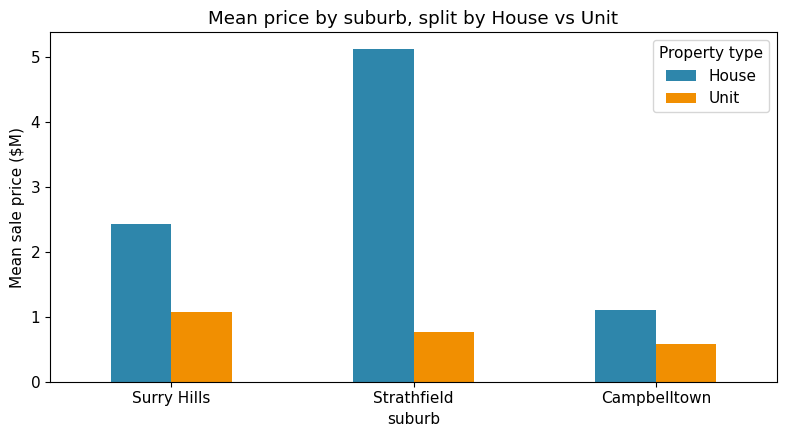

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = df[df.property_type.isin(['House', 'Unit'])]
grouped = plot_df.groupby(['suburb', 'property_type'])['sale_price'].mean().unstack() / 1e6
grouped = grouped.reindex(SUBURBS)
grouped.plot(kind='bar', ax=ax, color=['#2E86AB', '#F18F01'])
ax.set_ylabel('Mean sale price ($M)')
ax.set_title('Mean price by suburb, split by House vs Unit')
ax.set_xticklabels(SUBURBS, rotation=0)
ax.legend(title='Property type')
plt.tight_layout()
plt.show()

The ANOVA shows that **suburb is a significant factor in sale price (p < 0.001)**. The mean prices show the same general pattern within both houses and units, with Strathfield having the highest average prices in both groups, which suggests the suburb effect is not explained only by the property-type mix. Strathfield houses have higher average prices than houses in Surry Hills and Campbelltown, and the same pattern is seen for units. This indicates that the difference is not only due to the mix of houses and units. **Location is therefore an important factor in sale price.**

### 2.2b Checking suburb differences using log(price)

Section 2.1 established that `log(sale_price)` is the actual modelling target because it is far less skewed than raw price. The ANOVA above was run on raw `sale_price` for consistency with Part 1's reporting; it is repeated here on the log scale to check whether the suburb effect is still present once the extreme right-skew of raw prices is removed.

In [23]:
log_groups = [np.log(df.loc[df.suburb == s, 'sale_price']) for s in SUBURBS]
f_stat_log, p_val_log = sstats.f_oneway(*log_groups)

grand_mean_log = np.log(df['sale_price']).mean()
ss_between_log = sum(len(g) * (g.mean() - grand_mean_log) ** 2 for g in log_groups)
ss_total_log = ((np.log(df['sale_price']) - grand_mean_log) ** 2).sum()
eta_sq_suburb_log = ss_between_log / ss_total_log

print(f"One-way ANOVA (log(sale_price) ~ suburb): F = {f_stat_log:.1f}, p = {p_val_log:.2e}")
print(f"Eta-squared (suburb, log scale): {eta_sq_suburb_log:.3f} -> suburb explains ~{eta_sq_suburb_log*100:.1f}% of log-price variance")


One-way ANOVA (log(sale_price) ~ suburb): F = 33.0, p = 6.80e-13
Eta-squared (suburb, log scale): 0.271 -> suburb explains ~27.1% of log-price variance


The suburb effect is confirmed on the log scale: the association remains statistically significant and the effect size is stable relative to the raw-price result, so the raw-scale conclusion in Section 2.2 was not being driven by a handful of extreme high-value sales.


## 2.3 Trends over time

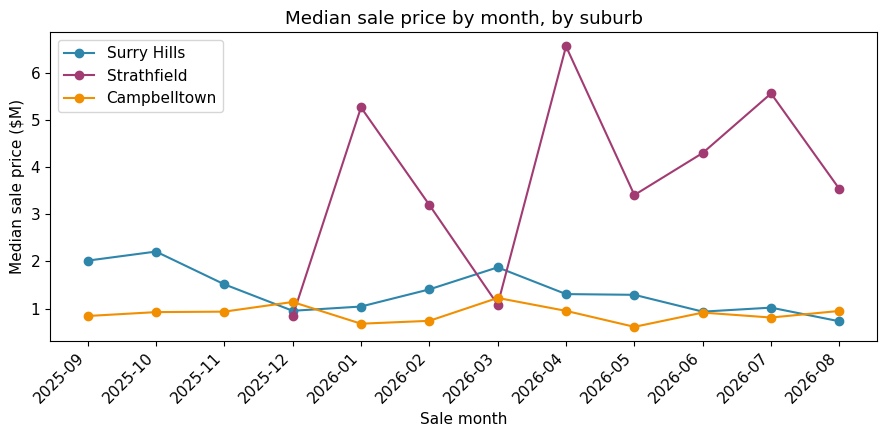

In [24]:
df['sale_month'] = df['sale_date'].dt.to_period('M')
monthly = df.groupby(['sale_month', 'suburb'])['sale_price'].median().unstack().reindex(columns=SUBURBS)

fig, ax = plt.subplots(figsize=(9, 4.5))
for s in SUBURBS:
 ax.plot(monthly.index.astype(str), monthly[s] / 1e6, marker='o', label=s, color=COLORS[s])
ax.set_ylabel('Median sale price ($M)')
ax.set_xlabel('Sale month')
ax.set_title('Median sale price by month, by suburb')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
monthly_counts = df.groupby(['sale_month', 'suburb']).size().unstack().reindex(columns=SUBURBS)
monthly_counts

suburb,Surry Hills,Strathfield,Campbelltown
sale_month,,,
2025-09,2.0,NaN,2.0
2025-10,7.0,NaN,9.0
2025-11,10.0,NaN,6.0
2025-12,2.0,11.0,7.0
2026-01,1.0,2.0,2.0
2026-02,8.0,11.0,7.0
2026-03,7.0,12.0,7.0
2026-04,4.0,3.0,2.0
2026-05,7.0,7.0,5.0


Month-to-month median prices are **noisy**, which is expected with only around **5 sales per suburb per month**. No reliable seasonal pattern or clear price trend can be identified across the **11-month period**. The monthly changes are more likely to reflect sampling variation than actual seasonal effects. This supports the conclusion that the collection period is too short to model time-based effects reliably. Therefore, `sale_date` is used in Part 3 to create **simple month or quarter features** rather than a continuous time-trend variable.

## 2.4 Outlier detection

In [26]:
def iqr_outliers(s):
 q1, q3 = s.quantile([0.25, 0.75])
 iqr = q3 - q1
 lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
 return (s < lower) | (s > upper)

df['price_outlier_iqr'] = False
for s in SUBURBS:
 mask = df['suburb'] == s
 df.loc[mask, 'price_outlier_iqr'] = iqr_outliers(df.loc[mask, 'sale_price'])

print(df['price_outlier_iqr'].sum(), "properties flagged as price outliers (suburb-wise IQR rule)")
df[df['price_outlier_iqr']][['property_id','suburb','property_type','bedrooms','sale_price']].sort_values(['suburb','sale_price'])

2 properties flagged as price outliers (suburb-wise IQR rule)


,property_id,suburb,property_type,bedrooms,sale_price
75,ST016,Strathfield,House,7,12050000
24,SH025,Surry Hills,Semi/Terrace,4,5000000


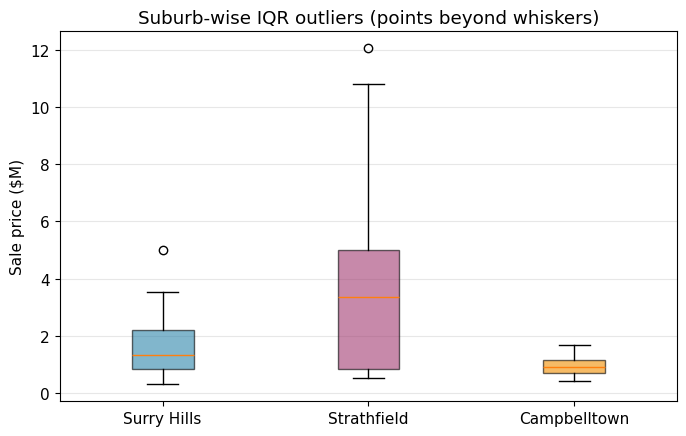

In [27]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [df[df.suburb == s]['sale_price'] / 1e6 for s in SUBURBS]
bp = ax.boxplot(data, tick_labels=SUBURBS, patch_artist=True, showfliers=True)
for patch, s in zip(bp['boxes'], SUBURBS):
 patch.set_facecolor(COLORS[s]); patch.set_alpha(0.6)
ax.set_ylabel('Sale price ($M)')
ax.set_title('Suburb-wise IQR outliers (points beyond whiskers)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The standard **1.5×IQR rule within each suburb** identifies a small number of high-value sales, mainly in Strathfield. Using suburb-specific thresholds is more appropriate than combining all suburbs because Strathfield has a higher overall price level. These extreme values appear to be **genuine high-value sales**, so they are retained to allow the model to represent the upper end of the market.

`CB029` (16 bedrooms, 9 bathrooms, **\$1.525M**) is not flagged as a price outlier because \$1.525M is typical for Campbelltown, even though its bedroom and bathroom counts are unusual. Price-based outlier detection therefore misses some records that a feature-based check would catch.

In [28]:
# Structural plausibility check: bedroom count relative to land size, independent of price
df['beds_per_100sqm_land'] = df['bedrooms'] / (df['land_size_sqm'] / 100)
structurally_odd = df[df['bedrooms'] >= 8][['property_id','suburb','bedrooms','bathrooms','land_size_sqm','sale_price']]
structurally_odd

,property_id,suburb,bedrooms,bathrooms,land_size_sqm,sale_price
148,CB029,Campbelltown,16,9.0,797.0,1525000


**Decision:** `CB029` is excluded from the **Part 3 modelling dataset** from the primary modelling analysis as a structurally atypical observation. Its combination of **16 bedrooms, 9 bathrooms, and a 797 sqm block** is unusually structured relative to the other residential records and could distort the relationship between bedroom count and sale price. All **price-based IQR outliers are retained** because they represent genuine high-value properties.


In [29]:
df_clean = df[df['property_id'] != 'CB029'].copy().reset_index(drop=True)
print(f"Rows before exclusion: {len(df)} -> rows after excluding CB029: {len(df_clean)}")

Rows before exclusion: 180 -> rows after excluding CB029: 179


## 2.5 Three candidate predictors before feature engineering

Before engineering any new features, the strength of the relationship between each **raw collected variable** and sale price is examined. This descriptive analysis identifies variables that are associated with price and allows the initial market expectations to be compared with the observed data. These statistics are not used as an automated feature-selection rule for modelling.

**Stated expectation before computing any statistics:** Based on general knowledge of the Sydney property market and the suburb differences identified in Part 1, **suburb**, **land size**, and **property type** were expected to be the three strongest predictors. This expectation was based on higher land values and limited land availability in inner-Sydney locations. The analysis below tests whether the collected data supports this expectation.

In [30]:
results = []

# Categorical predictors -> eta-squared from one-way ANOVA
for cat_col in ['suburb', 'property_type']:
 groups = [g['sale_price'].values for _, g in df_clean.groupby(cat_col) if len(g) > 1]
 f_stat, p_val = sstats.f_oneway(*groups)
 gm = df_clean['sale_price'].mean()
 ss_b = sum(len(g) * (g.mean() - gm) ** 2 for g in [df_clean.loc[df_clean[cat_col] == c, 'sale_price'] for c in df_clean[cat_col].unique()])
 ss_t = ((df_clean['sale_price'] - gm) ** 2).sum()
 eta_sq = ss_b / ss_t
 results.append({'feature': cat_col, 'type': 'categorical', 'effect_size': round(eta_sq, 3),
 'metric': 'eta-squared', 'p_value': p_val})

# Numeric predictors -> Pearson correlation with log price (available rows only)
for num_col in ['bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm', 'floor_area_sqm', 'distance_to_cbd_km']:
 valid = df_clean[[num_col, 'sale_price']].dropna()
 r, p_val = sstats.pearsonr(valid[num_col], np.log(valid['sale_price']))
 results.append({'feature': num_col, 'type': 'numeric', 'effect_size': round(r, 3),
 'metric': 'pearson r (vs log price)', 'p_value': p_val, 'n': len(valid)})

effect_df = pd.DataFrame(results).sort_values('effect_size', key=lambda s: s.abs(), ascending=False)
effect_df

,feature,type,effect_size,metric,p_value,n
4,car_spaces,numeric,0.721,pearson r (vs log price),2.189720e-23,138.0
2,bedrooms,numeric,0.656,pearson r (vs log price),2.007203e-23,179.0
3,bathrooms,numeric,0.640,pearson r (vs log price),9.667318e-22,177.0
6,floor_area_sqm,numeric,0.394,pearson r (vs log price),2.479700e-04,82.0
5,land_size_sqm,numeric,0.384,pearson r (vs log price),1.041049e-04,97.0
7,distance_to_cbd_km,numeric,-0.344,pearson r (vs log price),2.386765e-06,179.0
0,suburb,categorical,0.298,eta-squared,3.178069e-14,NaN
1,property_type,categorical,0.260,eta-squared,1.890542e-11,NaN


**Reading the Evidence Table**

* Among the **numeric predictors**, the strongest associations with log price are `car_spaces` (r = 0.721), `bedrooms` (r = 0.656), and `bathrooms` (r = 0.640). These are stronger than `floor_area_sqm` (r = 0.394) and `land_size_sqm` (r = 0.384). This suggests that, in this sample, functional features have a stronger association with price than property size alone.

* However, `car_spaces` is available for only 138 of 179 properties, with missing values mainly occurring for inner-city units. Its strong correlation may also partly reflect differences in `suburb` and `property_type`. Similar effects may apply to `bedrooms` and `bathrooms`.

* Among the **categorical predictors**, `suburb` has the largest effect (eta-squared = 0.298), explaining approximately 30% of the variation in raw price. `property_type` also has a substantial effect (eta-squared = 0.260). `distance_to_cbd_km` is correlated with price, but its values are identical within each suburb, so it does not add information beyond suburb itself.

**Three candidate predictors identified during EDA**

Based on the exploratory evidence, domain reasoning, and data availability, the three variables highlighted as candidate predictors are:

1. **`suburb`** to captures the location effect.
2. **`property_type`** to captures differences between dwelling types.
3. **`bedrooms`** to provides a strong numeric predictor with good data availability.

Although `car_spaces` has a slightly stronger correlation with price, it has substantial missing data and is closely related to `suburb` and `property_type`. `bedrooms` was therefore considered the more consistent numeric candidate.

This result differs from the initial expectation that `land_size_sqm` would be one of the strongest predictors. In this sample, **bedrooms have a stronger relationship with price**, so this variable was identified as the stronger candidate instead.

**Reconciling with Section 1.10:** The correlations differ slightly because Section 2.5 uses **log price**, excludes `CB029`, and uses pairwise observations for each variable. These differences explain the changes in the reported correlations.

**Exploratory feature assessment:** The three variables above were identified as candidate predictors during exploratory analysis. The correlations and eta-squared values were calculated on the 179-property analysis dataset for descriptive EDA and to compare the observed evidence with the initial market expectations; they do **not** determine which variables enter the predictive models. The final modelling feature set is guided by domain reasoning, property-valuation relevance, and data availability rather than selecting predictors solely according to full-sample correlations. All model fitting and learned preprocessing, including imputation, are performed only after the train/test split and are refitted within cross-validation folds.


## 2.6 Feature engineering

Based on the findings above, the raw variables are cleaned and extended to create a **modelling-ready feature set**.

In [31]:
fe = df_clean.copy()

fe['log_sale_price'] = np.log(fe['sale_price'])
fe['sale_quarter'] = fe['sale_date'].dt.quarter

# The remaining engineered features are created later inside
# HousingFeatureEngineer so the imputation values are learned from the
# appropriate training data.

# Descriptive check only. Price per sqm is calculated from sale price, so it is
# not used as a model input because that would leak the target.
fe['land_size_descriptive'] = fe.groupby(['suburb', 'property_type'])['land_size_sqm'].transform(lambda s: s.fillna(s.median())).fillna(0)
fe['price_per_sqm_land'] = np.where(fe['land_size_descriptive'] > 0, fe['sale_price'] / fe['land_size_descriptive'], np.nan)

fe[['property_id','suburb','property_type','bedrooms','bathrooms','car_spaces',
 'land_size_sqm','floor_area_sqm','sale_quarter','log_sale_price']].head(6)


,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,floor_area_sqm,sale_quarter,log_sale_price
0,SH001,Surry Hills,Unit,1,1.0,NaN,NaN,48.0,3,13.527828
1,SH002,Surry Hills,Unit,1,1.0,NaN,NaN,60.0,3,13.473020
2,SH003,Surry Hills,Unit,2,1.0,1.0,NaN,104.0,3,14.077875
3,SH004,Surry Hills,Unit,1,1.0,NaN,NaN,73.0,3,13.514405
4,SH005,Surry Hills,House,2,1.0,NaN,68.0,NaN,2,14.652758
5,SH006,Surry Hills,Unit,3,2.0,2.0,NaN,143.0,2,14.902388


In [32]:
print("price_per_sqm_land by suburb (median, houses only, descriptive):")
print(fe[fe.property_type == 'House'].groupby('suburb')['price_per_sqm_land'].median().reindex(SUBURBS).round(0))

price_per_sqm_land by suburb (median, houses only, descriptive):
suburb
Surry Hills     26857.0
Strathfield      5970.0
Campbelltown     1749.0
Name: price_per_sqm_land, dtype: float64


`price_per_sqm_land` is included only as a **descriptive cross-check**. The much lower land $/sqm value in Campbelltown compared with Strathfield is consistent with the outer- and middle-ring differences discussed in Part 1. However, it is **not used as a model input** because it is calculated directly from sale price and would cause **target leakage**.

### Engineered features used in Part 3

The final feature set includes:

- **Categorical features:** `suburb`, `property_type` (one-hot encoded)
- **Numeric features:** `land_size_filled`, `floor_area_filled`, `bedrooms`, `bathrooms`, `car_spaces_filled`, `total_rooms`, `bed_bath_ratio`
- **Binary features:** `has_car_space`, `is_unit`, `land_size_missing`, `floor_area_missing`, `car_spaces_missing`
- **Time feature:** `sale_quarter` (used as a coarse seasonality feature)

The modelling target is **`log_sale_price`**, with predictions back-transformed to dollars for reporting.

## 2.7 Comparing feature engineering with my initial expectations

The feature engineering **partly aligns with the initial market understanding**. Section 2.5 confirmed that **location and property type are important price drivers**. However, the expectation that `land_size_sqm` would be the third strongest predictor was not supported. `bedrooms` had a stronger correlation with price (r = 0.656) than `land_size_sqm` (r = 0.384), so `bedrooms` was identified as a stronger candidate predictor. This shows that market knowledge can guide the analysis, while exploratory evidence can be used to check whether those expectations are reasonable.

Other feature-engineering decisions were based on the dataset. `distance_to_cbd_km` was excluded because it is perfectly linked to `suburb`. Missing values in `land_size_sqm`, `floor_area_sqm`, and `car_spaces` were handled using imputation and **missingness flags**, as missingness appeared related to property type and location. `sale_date` was converted into a **quarter feature** because the approximately 11-month collection period did not show a reliable time trend.

Although `land_size_sqm` and `floor_area_sqm` were not among the three strongest individual predictors, they were retained because weaker features can still provide useful information when combined with other variables in the model.


# Part 3: Model Development and Evaluation

Three regression models representing different modelling approaches are developed, compared using k-fold cross-validation, and critically evaluated for underfitting/overfitting before a final recommendation is made.

## 3.1 Modelling dataset and preprocessing pipeline

### 3.1a Shared feature-engineering module

`HousingFeatureEngineer` was previously defined twice: once in this notebook and once in `app.py` (Section 6.3). Maintaining two copies of the same class could cause inconsistencies if a change is made to one but not the other. This could lead to differences between the model trained in the notebook and the model used by the deployed app.

To avoid this issue, the cell below saves the class in a single file, `housing_transformer.py`. The notebook imports this file for training, and `app.py` imports the same file for inference (Section 6.3). Both files were included when deploying the application (see Section 6.4).

In [33]:
%%writefile housing_transformer.py
"""Feature engineering used by both the notebook and Streamlit app."""

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class HousingFeatureEngineer(BaseEstimator, TransformerMixin):
    """Create the features used by the housing models."""

    OUTPUT_NUM = [
        'bedrooms', 'bathrooms', 'car_spaces_filled', 'land_size_filled',
        'floor_area_filled', 'total_rooms', 'bed_bath_ratio', 'has_car_space',
        'is_unit', 'land_size_missing', 'floor_area_missing',
        'car_spaces_missing', 'sale_quarter'
    ]
    OUTPUT_CAT = ['suburb', 'property_type']

    def fit(self, X, y=None):
        df = X.copy()
        self.land_medians_ = (
            df.groupby(['suburb', 'property_type'])['land_size_sqm'].median()
        )
        self.floor_medians_ = (
            df.groupby('property_type')['floor_area_sqm'].median()
        )
        self.floor_median_global_ = df['floor_area_sqm'].median()
        self.bathrooms_median_ = df['bathrooms'].median()
        return self

    def _impute_land(self, row):
        if pd.notna(row['land_size_sqm']):
            return row['land_size_sqm']

        key = (row['suburb'], row['property_type'])
        val = self.land_medians_.get(key, np.nan)
        return val if pd.notna(val) else 0.0

    def _impute_floor(self, row):
        if pd.notna(row['floor_area_sqm']):
            return row['floor_area_sqm']

        val = self.floor_medians_.get(row['property_type'], np.nan)
        return val if pd.notna(val) else self.floor_median_global_

    def transform(self, X):
        df = X.copy()
        out = pd.DataFrame(index=df.index)

        out['land_size_missing'] = df['land_size_sqm'].isna().astype(int)
        out['floor_area_missing'] = df['floor_area_sqm'].isna().astype(int)
        out['car_spaces_missing'] = df['car_spaces'].isna().astype(int)

        out['car_spaces_filled'] = df['car_spaces'].fillna(0)
        out['land_size_filled'] = df.apply(self._impute_land, axis=1)
        out['floor_area_filled'] = df.apply(self._impute_floor, axis=1)

        bathrooms_filled = df['bathrooms'].fillna(self.bathrooms_median_)

        out['bedrooms'] = df['bedrooms']
        out['bathrooms'] = df['bathrooms']
        out['total_rooms'] = df['bedrooms'] + bathrooms_filled
        out['bed_bath_ratio'] = (
            df['bedrooms'] / bathrooms_filled.replace(0, 1)
        )
        out['has_car_space'] = (out['car_spaces_filled'] > 0).astype(int)
        out['is_unit'] = (df['property_type'] == 'Unit').astype(int)
        out['sale_quarter'] = df['sale_quarter']
        out['suburb'] = df['suburb']
        out['property_type'] = df['property_type']

        return out[self.OUTPUT_NUM + self.OUTPUT_CAT]


Overwriting housing_transformer.py


In [34]:
from sklearn.model_selection import train_test_split, KFold, cross_validate, learning_curve, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone, BaseEstimator, TransformerMixin
from housing_transformer import HousingFeatureEngineer # shared with app.py -- see Section 3.1a

FEATURES_NUM = HousingFeatureEngineer.OUTPUT_NUM
FEATURES_CAT = HousingFeatureEngineer.OUTPUT_CAT
RAW_INPUT_COLS = ['suburb', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces',
 'land_size_sqm', 'floor_area_sqm', 'sale_quarter']

X = fe[RAW_INPUT_COLS].copy()
y = fe['log_sale_price'].copy()
y_dollars = fe['sale_price'].copy()

idx_train, idx_test = train_test_split(
 fe.index, test_size=0.2, random_state=42, stratify=fe['suburb']
)
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]
ydol_train, ydol_test = y_dollars.loc[idx_train], y_dollars.loc[idx_test]

print(f"Train: {X_train.shape[0]} rows | Held-out test: {X_test.shape[0]} rows")
print("All median-based imputation (land size, floor area, bathrooms) is fit INSIDE the "
 "pipeline below via HousingFeatureEngineer, so it is refit fresh on each CV fold's "
 "training partition, on X_train as a whole for the holdout check, and on the full "
 "dataset only at final deployment -- never on data that includes the rows being predicted.")

preprocess = Pipeline([
 ('engineer', HousingFeatureEngineer()),
 ('columns', ColumnTransformer([
 ('num', SimpleImputer(strategy='median'), FEATURES_NUM),
 ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT),
 ])),
])


Train: 143 rows | Held-out test: 36 rows
All median-based imputation (land size, floor area, bathrooms) is fit INSIDE the pipeline below via HousingFeatureEngineer, so it is refit fresh on each CV fold's training partition, on X_train as a whole for the holdout check, and on the full dataset only at final deployment -- never on data that includes the rows being predicted.


With only 180 observations (179 after excluding `CB029`), using a large held-out test set would leave limited data for training. The workflow therefore uses 5-fold cross-validation on an 80% training split for model comparison and overfitting checks, followed by a single held-out 20% test set for final independent evaluation. The 80/20 split is stratified by suburb so that all three markets are represented in both the training and test sets.

All group-median imputation for land size, floor area, and bathrooms is handled within a single `HousingFeatureEngineer` transformer, which is the first step in the modelling pipeline. As a scikit-learn transformer, `cross_validate` and `cross_val_predict` refit it using only each fold's training data. The same transformer is fitted on `X_train` for the holdout check in Section 3.5 and on the full dataset only for final deployment in Section 6.2, when no held-out evaluation remains. This ensures that the medians used for imputation are not calculated using the data from the row being predicted.

The only full-sample calculation in this notebook is `price_per_sqm_land` (Section 2.6). This is used for descriptive analysis only and is not included in the feature set, so it does not introduce leakage into the modelling process.



## 3.2 Model selection: three regression approaches

**Before training**, three models were selected to represent different modelling approaches and to establish an expected ranking.

| Model | Approach | Why chosen | Expected strengths | Expected weaknesses |
| ------------------------------- | ------------------------------ | ------------------------------------------------------------------------ | ---------------------------------------------------------------- | ------------------------------------------------------------------------------------------- |
| **Ridge Regression** | Linear, regularised | Provides an interpretable baseline with explainable coefficients | Low variance, fast, and unlikely to overfit | Cannot capture complex non-linear relationships or interactions without additional features |
| **Random Forest Regressor** | Bagged decision-tree ensemble | Captures non-linear relationships and feature interactions automatically | Handles interactions well and reduces variance through averaging | Limited data per suburb may make some splits unreliable |
| **Gradient Boosting Regressor** | Boosted decision-tree ensemble | Sequentially improves predictions by correcting previous errors | Can capture complex patterns and achieve low bias | More likely to overfit a small dataset if not constrained |

**Stated Expectation Before Training:** Based on the **non-linear relationships between suburb, property type, and price** identified in Part 2, both tree-based models were expected to outperform Ridge in predictive accuracy. **Random Forest was expected to generalise better than Gradient Boosting** because the dataset is small (`n = 179`). Ridge was expected to have lower accuracy but a **smaller training-CV performance gap**, indicating less overfitting.


In [35]:
models = {
 'Ridge Regression': Pipeline([
 ('prep', clone(preprocess)), # same HousingFeatureEngineer + ColumnTransformer as the tree models,
 # so all three models see an identical, leakage-safe feature set
 ('scale', StandardScaler(with_mean=False)), # with_mean=False keeps this safe whether the
 # ColumnTransformer output is sparse or dense
 ('model', Ridge(alpha=1.0, random_state=42)),
 ]),
 'Random Forest': Pipeline([
 ('prep', clone(preprocess)), # cloned so each pipeline owns an independent, unfitted transformer
 ('model', RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=42)),
 ]),
 'Gradient Boosting': Pipeline([
 ('prep', clone(preprocess)), # cloned so each pipeline owns an independent, unfitted transformer
 ('model', GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)),
 ]),
}
print("Models defined:", list(models.keys()))


Models defined: ['Ridge Regression', 'Random Forest', 'Gradient Boosting']


Random Forest and Gradient Boosting were originally given constrained settings (limited tree depth, minimum leaf size) chosen by hand, on the reasoning that the small dataset (`n = 179`) increases the risk of overfitting. That choice was an assumption rather than a demonstrated search. Section 3.2b below replaces the hand-picked values with a `GridSearchCV` search carried out on the training split. The selected hyperparameters are then used in the later model comparisons. Because the same training data is used for tuning and the later CV summaries, I treat those CV results as model-selection estimates rather than a fully independent performance estimate. The untouched 20% holdout set is used once at the end as the independent final check. Section 3.2c then checks a related concern: whether Ridge underperforms the tree models because it is a weaker learner, or simply because it was never given the suburb×property_type interaction information that trees can discover automatically.

All three models, including Ridge, use the same `HousingFeatureEngineer` and `ColumnTransformer` preprocessing block, with a separate cloned pipeline for each model. This ensures that differences in cross-validated performance reflect differences between the modelling approaches rather than differences in how the input data was prepared.

### 3.2b Hyperparameter tuning

Random Forest and Gradient Boosting are tuned using `GridSearchCV` with 5-fold cross-validation on the **training split only**. The held-out 20% test set is not used during tuning. The search grids are intentionally small because the training set contains only 143 observations.

The purpose of this search is **model selection**, not final performance estimation. Because the same training data are used first to choose the best hyperparameters and then to summarise cross-validation performance in Sections 3.3-3.4, those post-tuning CV results may be mildly optimistic. They are therefore reported as **model-selection estimates** rather than fully independent estimates of generalisation performance.

A nested cross-validation design (an outer CV loop for evaluation and an inner CV loop for hyperparameter tuning) could provide a less biased CV estimate. However, given the small dataset and the scope of this mini-project, the simpler workflow is retained. The untouched **20% holdout set in Section 3.5 is treated as the final independent evaluation** and is used only after model selection is complete. Ridge Regression remains at `alpha=1.0` because it is used primarily as a regularised linear baseline.


In [36]:
from sklearn.model_selection import GridSearchCV, KFold as _KFold

kf_search = _KFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = {
 'model__n_estimators': [200, 300, 400],
 'model__max_depth': [4, 6, 8],
 'model__min_samples_leaf': [2, 3, 5],
}
gbm_grid = {
 'model__n_estimators': [100, 200, 300],
 'model__max_depth': [2, 3, 4],
 'model__learning_rate': [0.03, 0.05, 0.1],
}

# n_jobs=1 avoids the Windows memory error I had when running GridSearchCV.
rf_search = GridSearchCV(models['Random Forest'], rf_grid, cv=kf_search,
 scoring='r2', n_jobs=1, refit=True)
rf_search.fit(X_train, y_train)

gbm_search = GridSearchCV(models['Gradient Boosting'], gbm_grid, cv=kf_search,
 scoring='r2', n_jobs=1, refit=True)
gbm_search.fit(X_train, y_train)

print("Random Forest -- best CV R2:", round(rf_search.best_score_, 3), "| best params:", rf_search.best_params_)
print("Gradient Boosting -- best CV R2:", round(gbm_search.best_score_, 3), "| best params:", gbm_search.best_params_)

models['Random Forest'] = rf_search.best_estimator_
models['Gradient Boosting'] = gbm_search.best_estimator_

Random Forest -- best CV R2: 0.89 | best params: {'model__max_depth': 6, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
Gradient Boosting -- best CV R2: 0.908 | best params: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 200}


### 3.2c Checking Ridge with interaction terms

Section 3.6 states that tree models "better capture non-linear relationships". However, this comparison may be affected by Ridge not having explicit suburb × property_type interaction terms, while tree models can learn such interactions from the available features. This section gives Ridge an explicit interaction feature and re-evaluates its performance. The aim is to determine whether Ridge is a weaker learner or whether it was not given the same information as the tree models. If the interaction version reduces the performance gap, the claim in Section 3.6 should be softened accordingly.

In [37]:
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer

# ColumnTransformer output may be sparse; PolynomialFeatures needs a dense array here.
densify = FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'toarray') else x, accept_sparse=True)

ridge_interact_pipe = Pipeline([
 ('prep', clone(preprocess)),
 ('densify', densify),
 ('interact', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
 ('scale', StandardScaler(with_mean=False)),
 ('model', Ridge(alpha=1.0, random_state=42)),
])

kf_local = KFold(n_splits=5, shuffle=True, random_state=42)

plain_ridge_r2 = cross_validate(models['Ridge Regression'], X_train, y_train, cv=kf_local,
 scoring='r2', return_train_score=False)['test_score'].mean()
ridge_interact_scores = cross_validate(ridge_interact_pipe, X_train, y_train, cv=kf_local,
 scoring='r2', return_train_score=False)

print("Plain Ridge -- CV R2 (log):", round(plain_ridge_r2, 3))
print("Ridge + interactions -- CV R2 (log):", round(ridge_interact_scores['test_score'].mean(), 3))
print()
print("If the interaction version closes most of the gap to the tree models, the original")
print("'trees capture non-linearity better' claim in Section 3.6 should be softened to")
print("'Ridge wasn't given the same interaction information, not that linear models are")
print("inherently worse on this problem.'")


Plain Ridge -- CV R2 (log): 0.882
Ridge + interactions -- CV R2 (log): 0.898

If the interaction version closes most of the gap to the tree models, the original
'trees capture non-linearity better' claim in Section 3.6 should be softened to
'Ridge wasn't given the same interaction information, not that linear models are
inherently worse on this problem.'


## 3.3 K-fold cross-validation results

The following 5-fold cross-validation results compare the three candidate models on the training split. For Random Forest and Gradient Boosting, the hyperparameters were selected using `GridSearchCV` on this same training split in Section 3.2b. Therefore, these CV summaries are interpreted as **model-selection estimates** and may be somewhat optimistic. They are useful for comparing candidate models and examining train-validation gaps, while the untouched holdout set in Section 3.5 provides the final independent performance check.


In [38]:
# RF and GB were tuned on X_train in Section 3.2b, so these CV results are used
# for model comparison. The untouched holdout in Section 3.5 is the final check.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'rmse_log': 'neg_root_mean_squared_error', 'mae_log': 'neg_mean_absolute_error', 'r2_log': 'r2'}

cv_results = {}
for name, pipe in models.items():
 res = cross_validate(pipe, X_train, y_train, cv=kf, scoring=scoring, return_train_score=True)
 cv_results[name] = res

cv_summary = pd.DataFrame({
 name: {
 'CV RMSE (log)': -res['test_rmse_log'].mean(),
 'CV RMSE (log) std': res['test_rmse_log'].std(),
 'CV MAE (log)': -res['test_mae_log'].mean(),
 'CV R2': res['test_r2_log'].mean(),
 'CV R2 std': res['test_r2_log'].std(),
 'Train R2': res['train_r2_log'].mean(),
 }
 for name, res in cv_results.items()
}).T.round(3)
cv_summary

,CV RMSE (log),CV RMSE (log) std,CV MAE (log),CV R2,CV R2 std,Train R2
Ridge Regression,0.266,0.050,0.217,0.882,0.033,0.917
Random Forest,0.260,0.034,0.193,0.890,0.014,0.972
Gradient Boosting,0.235,0.042,0.179,0.908,0.024,0.995


RMSE and MAE above are on the **log-price** scale. To make the comparison interpretable for a real-estate stakeholder, the same candidate models are also scored in **back-transformed dollar terms** using out-of-fold predictions. Because RF/GB tuning was performed on the same training split, these dollar CV metrics are also treated as **model-selection estimates**. The independent holdout results in Section 3.5 are used for the final assessment of generalisation.


In [39]:
from sklearn.model_selection import cross_val_predict

dollar_metrics = {}
for name, pipe in models.items():
 oof_log_pred = cross_val_predict(pipe, X_train, y_train, cv=kf)
 oof_dollar_pred = np.exp(oof_log_pred)
 pct_err = np.abs((ydol_train - oof_dollar_pred) / ydol_train) * 100
 dollar_metrics[name] = {
 'CV RMSE ($)': mean_squared_error(ydol_train, oof_dollar_pred) ** 0.5,
 'CV MAE ($)': mean_absolute_error(ydol_train, oof_dollar_pred),
 'CV R2 ($ scale)': r2_score(ydol_train, oof_dollar_pred),
 'CV MAPE (%)': pct_err.mean(),
 'CV Median APE (%)': pct_err.median(), # robust to the handful of extreme Strathfield errors
 }

dollar_df = pd.DataFrame(dollar_metrics).T.round(2)
dollar_df


,CV RMSE ($),CV MAE ($),CV R2 ($ scale),CV MAPE (%),CV Median APE (%)
Ridge Regression,996380.27,506434.76,0.77,22.50,18.44
Random Forest,912432.36,482427.81,0.81,19.97,13.45
Gradient Boosting,838064.43,452995.35,0.84,18.18,13.87


**Baseline comparison.** The suburb x property_type median is a trivial, no-modelling predictor. If an ML model's CV RMSE/MAPE isn't clearly better than this row, that model isn't earning its complexity. The baseline below is computed out-of-fold on the *same* 5 folds as the models above (each fold's baseline prediction uses medians from the other folds only), so the comparison is fair. Re-run this after Section 3.2b's tuning updates `models['Random Forest']` / `models['Gradient Boosting']`.

In [40]:
fe_train = fe.loc[X_train.index].reset_index(drop=True)
X_train_reset = X_train.reset_index(drop=True)
ydol_train_reset = ydol_train.reset_index(drop=True)

baseline_oof_pred = np.full(len(X_train_reset), np.nan)
for tr_idx, val_idx in kf.split(X_train_reset):
 lookup = fe_train.iloc[tr_idx].groupby(['suburb', 'property_type'])['sale_price'].median()
 overall_median = fe_train.iloc[tr_idx]['sale_price'].median()
 val_keys = list(zip(fe_train.iloc[val_idx]['suburb'], fe_train.iloc[val_idx]['property_type']))
 baseline_oof_pred[val_idx] = [lookup.get(k, overall_median) for k in val_keys]

baseline_pct_err = np.abs((ydol_train_reset.values - baseline_oof_pred) / ydol_train_reset.values) * 100

dollar_metrics['Naive suburb x type median'] = {
 'CV RMSE ($)': mean_squared_error(ydol_train_reset, baseline_oof_pred) ** 0.5,
 'CV MAE ($)': mean_absolute_error(ydol_train_reset, baseline_oof_pred),
 'CV R2 ($ scale)': r2_score(ydol_train_reset, baseline_oof_pred),
 'CV MAPE (%)': baseline_pct_err.mean(),
 'CV Median APE (%)': np.median(baseline_pct_err),
}

dollar_df = pd.DataFrame(dollar_metrics).T.round(2)
dollar_df

,CV RMSE ($),CV MAE ($),CV R2 ($ scale),CV MAPE (%),CV Median APE (%)
Ridge Regression,996380.27,506434.76,0.77,22.50,18.44
Random Forest,912432.36,482427.81,0.81,19.97,13.45
Gradient Boosting,838064.43,452995.35,0.84,18.18,13.87
Naive suburb x type median,1242494.99,622426.81,0.64,24.87,19.33


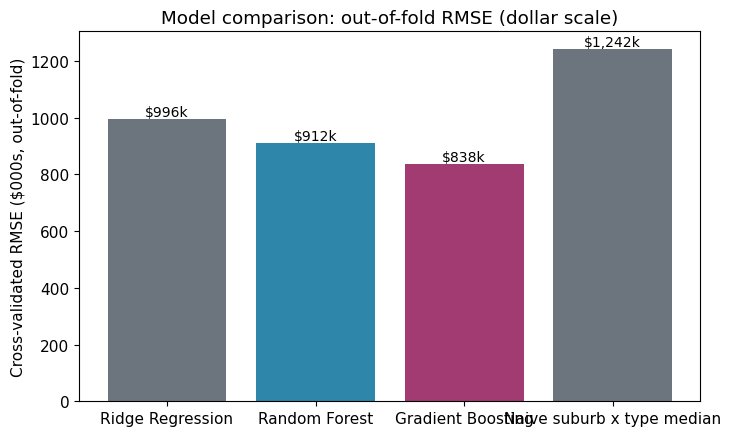

In [41]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
names = list(dollar_metrics.keys())
rmse_vals = [dollar_metrics[n]['CV RMSE ($)'] / 1e3 for n in names]
bars = ax.bar(names, rmse_vals, color=['#6C757D', '#2E86AB', '#A23B72'])
ax.set_ylabel('Cross-validated RMSE ($000s, out-of-fold)')
ax.set_title('Model comparison: out-of-fold RMSE (dollar scale)')
for b, v in zip(bars, rmse_vals):
 ax.text(b.get_x() + b.get_width()/2, v, f'${v:,.0f}k', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### 3.3b Residual checks

The plots use the same out-of-fold predictions to assess error distribution across the price range. Predictions generally track actual prices, but errors widen above approximately $5M. This suggests some heteroscedasticity at the high end, likely due to the small number of high-value Strathfield properties.

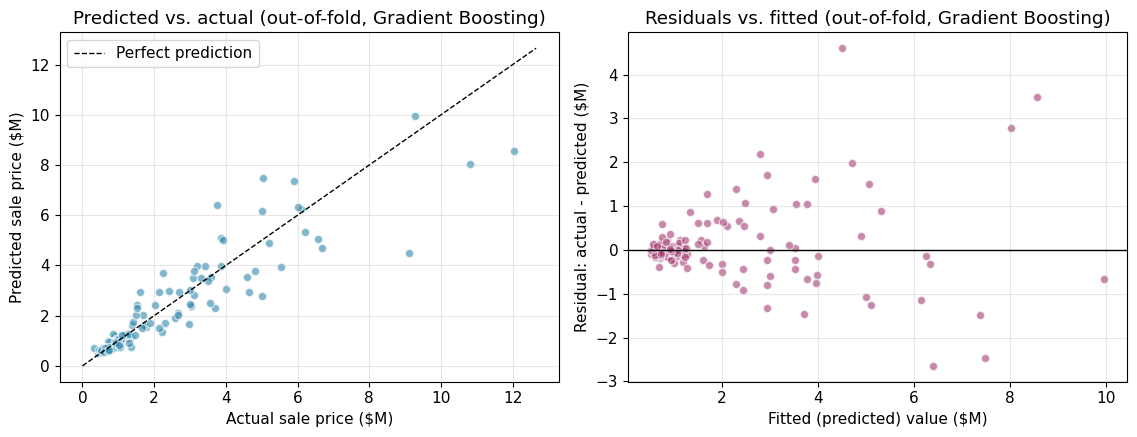

In [42]:
gbm_oof_log = cross_val_predict(models['Gradient Boosting'], X_train, y_train, cv=kf)
gbm_oof_dollar = np.exp(gbm_oof_log)
gbm_residuals = ydol_train.values - gbm_oof_dollar

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

axes[0].scatter(ydol_train / 1e6, gbm_oof_dollar / 1e6, alpha=0.6, color='#2E86AB', edgecolor='white')
lims = [0, max(ydol_train.max(), gbm_oof_dollar.max()) / 1e6 * 1.05]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual sale price ($M)'); axes[0].set_ylabel('Predicted sale price ($M)')
axes[0].set_title('Predicted vs. actual (out-of-fold, Gradient Boosting)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(gbm_oof_dollar / 1e6, gbm_residuals / 1e6, alpha=0.6, color='#A23B72', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Fitted (predicted) value ($M)'); axes[1].set_ylabel('Residual: actual - predicted ($M)')
axes[1].set_title('Residuals vs. fitted (out-of-fold, Gradient Boosting)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Both plots show that predictions track actual prices reasonably well across most of the price range, but the scatter widens above approximately $5M. The residuals-versus-fitted plot also shows larger residuals in both directions at higher fitted values rather than an even spread. This suggests some heteroscedasticity at the high end, consistent with a small number of high-value properties rather than a problem across the dataset as a whole.

## 3.4 Checking underfitting and overfitting

In [43]:
complexity_df = pd.DataFrame({
 name: {'Train R2 (log)': cv_results[name]['train_r2_log'].mean(),
 'CV R2 (log)': cv_results[name]['test_r2_log'].mean()}
 for name in models
}).T
complexity_df['Train - CV gap'] = complexity_df['Train R2 (log)'] - complexity_df['CV R2 (log)']
complexity_df.round(3)

,Train R2 (log),CV R2 (log),Train - CV gap
Ridge Regression,0.917,0.882,0.035
Random Forest,0.972,0.890,0.082
Gradient Boosting,0.995,0.908,0.087


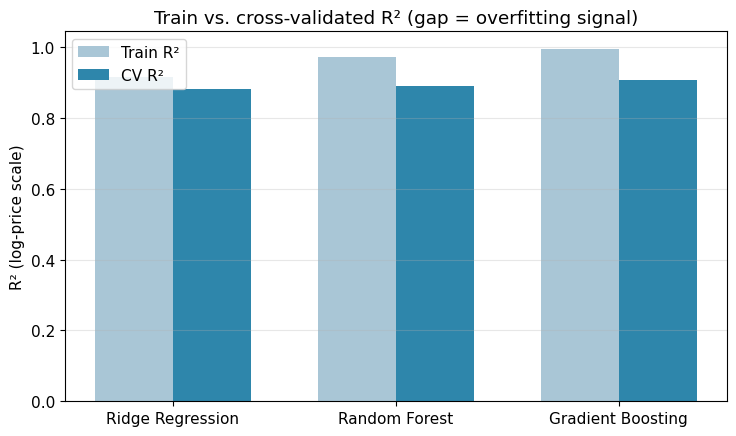

In [44]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, complexity_df['Train R2 (log)'], width, label='Train R²', color='#A9C6D6')
ax.bar(x + width/2, complexity_df['CV R2 (log)'], width, label='CV R²', color='#2E86AB')
ax.set_xticks(x); ax.set_xticklabels(models.keys())
ax.set_ylabel('R² (log-price scale)')
ax.set_title('Train vs. cross-validated R² (gap = overfitting signal)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

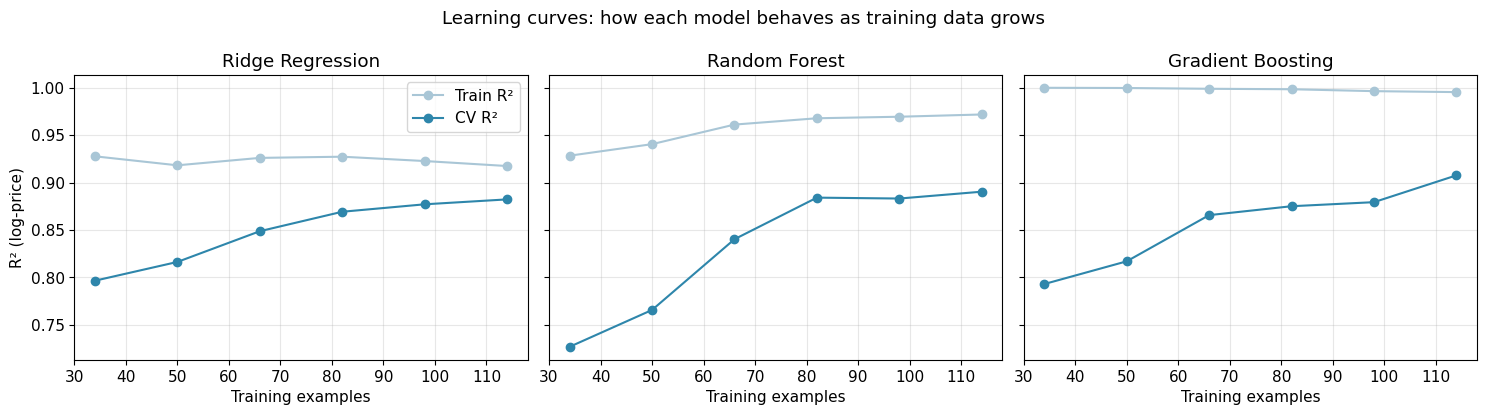

In [45]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (name, pipe) in zip(axes, models.items()):
 train_sizes, train_scores, val_scores = learning_curve(
 pipe, X_train, y_train, cv=kf, scoring='r2',
 train_sizes=np.linspace(0.3, 1.0, 6), random_state=42
 )
 ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#A9C6D6', label='Train R²')
 ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#2E86AB', label='CV R²')
 ax.set_title(name); ax.set_xlabel('Training examples')
 ax.grid(alpha=0.3)
axes[0].set_ylabel('R² (log-price)')
axes[0].legend()
plt.suptitle('Learning curves: how each model behaves as training data grows')
plt.tight_layout()
plt.show()

**Model Overfitting Diagnosis**

| Model | Train R² (log) | CV R² (log) | Train-CV Gap |
| ----------------- | -------------: | ----------: | -----------: |
| Ridge Regression | 0.917 | 0.882 | **0.035** |
| Random Forest | 0.972 | 0.890 | 0.082 |
| Gradient Boosting | 0.995 | 0.908 | 0.087 |

* **Ridge Regression** has the smallest train-CV gap (0.035), indicating the least overfitting. However, its lower CV R² suggests that the linear model cannot fully capture the non-linear relationships between suburb, property type, and price.

* **Random Forest and Gradient Boosting** have similar gaps (0.082 and 0.087), showing more overfitting than Ridge. This is expected given their greater flexibility and the small dataset (`n = 179`).

* The results do not support the expectation that Gradient Boosting would overfit more than Random Forest by a wide margin. The searched settings (`max_depth=4`, `learning_rate=0.03`, `n_estimators=200`, from Section 3.2b's GridSearchCV) appear to have controlled its complexity about as well as Random Forest's.

* **Gradient Boosting achieved the highest CV R² (0.908)** despite its high training R² (0.995). Its strong cross-validation performance indicates that the model was not simply memorising the training data.

* The learning curves are consistent with these results. **Ridge shows some underfitting**, while the tree-based models benefit from greater flexibility. Gradient Boosting does not show severe separation between training and validation performance.

> **Caveat:** the ranking above (Ridge < Random Forest ≈ Gradient Boosting) is a *point-estimate* ranking. Section 3.4b's paired significance test shows Gradient Boosting is statistically distinguishable from Ridge (p = 0.047) but **not** from Random Forest (p = 0.305) at n=5 folds, so the Random Forest vs Gradient Boosting gap should be treated as indicative rather than statistically established.


### 3.4b Comparing model performance across folds

The `CV R2` values above show some differences between the models, but their standard deviations overlap substantially. With only 5 folds, differences in the average scores do not necessarily provide strong statistical evidence that one model is better than another. The cell below uses a paired t-test on the 5 fold scores for each pair of models to check whether the differences are statistically distinguishable.

The p-values should be interpreted cautiously because only 5 paired observations are available, which gives the test low statistical power. The "how to read this" note below the table should therefore be considered before using these p-values to support any model-ranking claims.

In [46]:
from scipy.stats import ttest_rel

fold_scores = {name: cv_results[name]['test_r2_log'] for name in models}

pairs = [('Gradient Boosting', 'Ridge Regression'),
 ('Gradient Boosting', 'Random Forest'),
 ('Random Forest', 'Ridge Regression')]

sig_results = []
for a, b in pairs:
 t_stat, p_val = ttest_rel(fold_scores[a], fold_scores[b])
 diff = fold_scores[a].mean() - fold_scores[b].mean()
 sig_results.append({
 'Comparison': f'{a} vs {b}',
 'Mean CV R2 diff': round(diff, 4),
 'Paired t p-value': round(p_val, 3),
 'Significant at 0.05?': 'Yes' if p_val < 0.05 else 'No',
 })

sig_df = pd.DataFrame(sig_results)
print("Note: with only 5 paired fold scores this test has very low statistical power --")
print("a 'No' here means 'not distinguishable at this sample size', not 'no real difference'.")
sig_df

Note: with only 5 paired fold scores this test has very low statistical power --
a 'No' here means 'not distinguishable at this sample size', not 'no real difference'.


,Comparison,Mean CV R2 diff,Paired t p-value,Significant at 0.05?
0,Gradient Boosting vs Ridge Regression,0.0260,0.047,Yes
1,Gradient Boosting vs Random Forest,0.0185,0.305,No
2,Random Forest vs Ridge Regression,0.0075,0.712,No


**How to read this table.** A non-significant result with only 5 folds does not prove that the models are equivalent. It means there is not enough evidence to confidently distinguish their performance. The point-estimate ranking in Section 3.3 should therefore be reported together with this table. For example: "Gradient Boosting had the best CV point estimate, but its difference from Random Forest was not statistically distinguishable with only 5 folds. The practical tie-breaker is Gradient Boosting's lower dollar-scale MAPE (Section 3.3) and its improvement over the naive baseline (Section 3.3)."

## 3.5 Final check on the held-out test set

In [47]:
holdout_results = {}
for name, pipe in models.items():
 pipe.fit(X_train, y_train)
 log_pred = pipe.predict(X_test)
 dollar_pred = np.exp(log_pred)
 holdout_results[name] = {
 'Holdout RMSE ($)': mean_squared_error(ydol_test, dollar_pred) ** 0.5,
 'Holdout MAE ($)': mean_absolute_error(ydol_test, dollar_pred),
 'Holdout R2 ($ scale)': r2_score(ydol_test, dollar_pred),
 'Holdout MAPE (%)': (np.abs((ydol_test - dollar_pred) / ydol_test)).mean() * 100,
 }

holdout_df = pd.DataFrame(holdout_results).T.round(2)
comparison = pd.concat([dollar_df[['CV RMSE ($)', 'CV MAE ($)', 'CV R2 ($ scale)']],
 holdout_df[['Holdout RMSE ($)', 'Holdout MAE ($)', 'Holdout R2 ($ scale)']]], axis=1)
comparison.round(2)

,CV RMSE ($),CV MAE ($),CV R2 ($ scale),Holdout RMSE ($),Holdout MAE ($),Holdout R2 ($ scale)
Ridge Regression,996380.27,506434.76,0.77,493139.61,327794.46,0.89
Random Forest,912432.36,482427.81,0.81,379712.88,214582.33,0.93
Gradient Boosting,838064.43,452995.35,0.84,348711.68,226011.73,0.94
Naive suburb x type median,1242494.99,622426.81,0.64,NaN,NaN,NaN


In [48]:
# Check whether differences in the train/test price mix help explain the CV and holdout gap.
print("Train sale_price: mean=${:,.0f}, std=${:,.0f}, max=${:,.0f}".format(
 ydol_train.mean(), ydol_train.std(), ydol_train.max()))
print("Test sale_price: mean=${:,.0f}, std=${:,.0f}, max=${:,.0f}".format(
 ydol_test.mean(), ydol_test.std(), ydol_test.max()))

train_strath_house_share = ((fe.loc[X_train.index, 'suburb'] == 'Strathfield') &
 (fe.loc[X_train.index, 'property_type'] == 'House')).mean() * 100
test_strath_house_share = ((fe.loc[X_test.index, 'suburb'] == 'Strathfield') &
 (fe.loc[X_test.index, 'property_type'] == 'House')).mean() * 100
print(f"\nShare of Strathfield houses -> train: {train_strath_house_share:.1f}%, test: {test_strath_house_share:.1f}%")


Train sale_price: mean=$2,092,280, std=$2,090,291, max=$12,050,000
Test sale_price: mean=$1,636,722, std=$1,488,602, max=$6,936,000

Share of Strathfield houses -> train: 21.7%, test: 16.7%


Holdout RMSE is substantially **lower than the post-tuning cross-validation RMSE** for all three models. For example, Gradient Boosting has a CV RMSE of approximately **\$838k** compared with **\$349k** on the holdout set. A likely explanation is that the 20% holdout set contained fewer extreme high-value Strathfield properties, which Part 4 identifies as the most difficult cases.

Because Random Forest and Gradient Boosting hyperparameters were selected using the same training split later summarised by cross-validation, the CV figures in Section 3.3 are treated as **model-selection estimates** rather than unbiased estimates of future performance. The holdout set was not used for tuning and therefore provides the **final independent performance check**. Its unusually low error should still be interpreted cautiously because this particular holdout sample appears easier than the training/CV samples.


## 3.6 Revisiting the original expectations

In [49]:
final_ranking = comparison.sort_values('CV RMSE ($)')[['CV RMSE ($)', 'Holdout RMSE ($)']]
final_ranking['CV rank'] = final_ranking['CV RMSE ($)'].rank().astype(int)
final_ranking

,CV RMSE ($),Holdout RMSE ($),CV rank
Gradient Boosting,838064.43,348711.68,1
Random Forest,912432.36,379712.88,2
Ridge Regression,996380.27,493139.61,3
Naive suburb x type median,1242494.99,NaN,4


**Was the Pre-Registered Expectation from Section 3.2 Supported?**

The results **partly support the original expectation**. Gradient Boosting had the best post-tuning CV point estimate (approximately **\$838k** RMSE), and the untouched holdout set independently produced the lowest RMSE for Gradient Boosting (approximately **\$349k**), followed by Random Forest and Ridge Regression.

* **Supported:** Both tree-based models outperformed Ridge Regression, supporting the expectation that their greater flexibility would better capture the non-linear relationships between suburb, property type, and price.

* **Not supported:** Random Forest was expected to generalise better than Gradient Boosting because of the small dataset. However, their train-CV gaps were almost identical (0.082 for Random Forest and 0.087 for Gradient Boosting), while Gradient Boosting achieved the best CV and holdout performance.

Overall, the **bias-variance reasoning was reasonable**, but the expected ranking between the ensemble models was not supported. The searched Gradient Boosting settings (Section 3.2b) controlled overfitting about as well as Random Forest and produced better generalisation than expected. This shows that **model complexity and tuning can be as important as algorithm choice**, particularly with a small dataset.

> **Caveat:** this ranking is a *point-estimate* ranking based on CV/holdout RMSE. Section 3.4b's paired significance test shows the gap between Gradient Boosting and Ridge Regression is statistically distinguishable (p = 0.047), but the gap between Gradient Boosting and Random Forest is **not** (p = 0.305) at n=5 folds, so "Gradient Boosting ranked first" should be read as the best point estimate with a practical (not statistically confirmed) edge over Random Forest, rather than a decisively separated top model.


## 3.7 Recommendation

Based on the results, **Gradient Boosting** is recommended as the primary model. It achieved the best post-tuning cross-validated **model-selection** RMSE (**≈ \$838k**) and lowest CV MAPE. The untouched holdout set, used only after tuning and model comparison, also gave Gradient Boosting the best RMSE (**≈ \$349k**), providing an independent final check. The searched settings from Section 3.2b's GridSearchCV (`max_depth = 4`, `learning_rate = 0.03`, `n_estimators = 200`) helped control overfitting while maintaining strong predictive performance; Section 3.4b shows this model is statistically distinguishable from Ridge Regression but not from Random Forest at n=5 folds, so Random Forest remains a close practical alternative.

However, the dataset contains only **179 observations**, and the high training R² (0.995) indicates that the model should be re-evaluated as more data become available. **Ridge Regression** is recommended as a secondary model because its coefficients are easier to interpret, and **Random Forest** performs similarly to Gradient Boosting and could be used as an alternative.


### 3.7b Checking model performance with and without CB029

Section 1.8 excluded `CB029` (16 bed / 9 bath on 797 sqm) from modelling as a structurally implausible record. To check how much this decision affects the results, the recommended model is retrained with the same CV setup on a dataset that includes CB029, and the two sets of metrics are compared.


In [50]:
# Rebuild the data with CB029 included while keeping the other steps the same.
fe_with_cb029 = df.copy()
fe_with_cb029['log_sale_price'] = np.log(fe_with_cb029['sale_price'])
fe_with_cb029['sale_quarter'] = fe_with_cb029['sale_date'].dt.quarter

X_with_cb029 = fe_with_cb029[RAW_INPUT_COLS].copy()
y_with_cb029 = fe_with_cb029['log_sale_price'].copy()
ydol_with_cb029 = fe_with_cb029['sale_price'].copy()

idx_train_wcb, idx_test_wcb = train_test_split(
 fe_with_cb029.index, test_size=0.2, random_state=42, stratify=fe_with_cb029['suburb']
)
X_train_wcb, y_train_wcb = X_with_cb029.loc[idx_train_wcb], y_with_cb029.loc[idx_train_wcb]
ydol_train_wcb = ydol_with_cb029.loc[idx_train_wcb]

# Use the same tuned Gradient Boosting settings so the only change is whether
# CB029 is included.
gbm_with_cb029 = clone(models['Gradient Boosting'])
oof_log_wcb = cross_val_predict(gbm_with_cb029, X_train_wcb, y_train_wcb, cv=kf)
oof_dollar_wcb = np.exp(oof_log_wcb)

cb029_comparison = pd.DataFrame({
 'Without CB029 (used in this notebook)': {
 'CV RMSE ($)': dollar_metrics['Gradient Boosting']['CV RMSE ($)'],
 'CV MAPE (%)': dollar_metrics['Gradient Boosting']['CV MAPE (%)'],
 'CV Median APE (%)': dollar_metrics['Gradient Boosting']['CV Median APE (%)'],
 'n (train)': len(X_train),
 },
 'With CB029 included': {
 'CV RMSE ($)': mean_squared_error(ydol_train_wcb, oof_dollar_wcb) ** 0.5,
 'CV MAPE (%)': (np.abs((ydol_train_wcb - oof_dollar_wcb) / ydol_train_wcb)).mean() * 100,
 'CV Median APE (%)': (np.abs((ydol_train_wcb - oof_dollar_wcb) / ydol_train_wcb) * 100).median(),
 'n (train)': len(X_train_wcb),
 },
}).T.round(2)
cb029_comparison


,CV RMSE ($),CV MAPE (%),CV Median APE (%),n (train)
Without CB029 (used in this notebook),838064.43,18.18,13.87,143.0
With CB029 included,830673.18,19.18,15.09,144.0


Including CB029 gives a mixed result rather than consistently improving or worsening performance. CV RMSE is slightly lower with CB029 included (**\$830,673** vs. **\$838,064**), while CV MAPE (19.18% vs. 18.18%) and Median APE (15.09% vs. 13.87%) are worse. Its unusual 16 bedrooms and 9 bathrooms with a \$1.525M sale price make it influential for percentage-based errors. The exclusion in Section 1.8 is therefore kept on structural grounds, not because removing it improves every metric. The difference is small and does not change the model ranking or Part 3 recommendation.


## 3.8 Data leakage checks

The main stages of the modelling process were checked for possible data leakage.

| **Stage** | **What I checked** | **Result** |
| --- | --- | --- |
| Features using sale price | `price_outlier_iqr` and `price_per_sqm_land` use the target | Used only for EDA, not as model features |
| `distance_to_cbd_km` | Closely related to suburb | Excluded from the final feature set |
| CB029 | Whether it was removed because of model performance | Excluded because it was unusual, not because of prediction error |
| Section 2.5 EDA | Correlations used the full dataset | Used to understand the data, not for automatic feature selection |
| Missing values | Whether validation/test information was used for imputation | Imputation was done inside the pipeline using the relevant training data |
| Train/test split | Whether splitting happened before preprocessing | Raw data was split before model fitting |
| CV and tuning | Same training split used for tuning and later CV summaries | A limitation, so these CV results are treated as model-comparison estimates |
| Holdout set | Whether it influenced tuning | Kept separate and used for the final evaluation |
| Part 5 | Whether reference medians used holdout data | Calculated from training data only |
| Deployment | Final model refitted on all 179 properties | Done only after evaluation was complete |

The preprocessing leakage was controlled by keeping learned preprocessing inside the pipeline. The main limitation is that Random Forest and Gradient Boosting were tuned on the same training split later used for the CV comparison. I therefore use the untouched holdout set as the final independent performance check.


# Part 4: Investigating Prediction Failures

Instead of using only the 36 properties in the holdout set, this section uses **out-of-fold predictions** for all 179 properties. This gives a prediction for each property using a model that did not train on that property. The five properties with the largest dollar errors are then examined to understand where the model performed poorly.

## 4.1 Out-of-fold predictions

In [51]:
oof_log_pred_all = cross_val_predict(models['Gradient Boosting'], X, y, cv=kf)
oof_dollar_pred_all = np.exp(oof_log_pred_all)

fe['pred_dollar'] = oof_dollar_pred_all
fe['abs_error'] = np.abs(fe['sale_price'] - fe['pred_dollar'])
fe['pct_error'] = fe['abs_error'] / fe['sale_price'] * 100
fe['signed_error'] = fe['pred_dollar'] - fe['sale_price'] # positive = model overestimated

print(f"Mean absolute error across all {len(fe)} properties: ${fe['abs_error'].mean():,.0f}")
print(f"Mean absolute percentage error: {fe['pct_error'].mean():.1f}%")

Mean absolute error across all 179 properties: $377,441
Mean absolute percentage error: 16.1%


## 4.2 The five largest prediction errors

In [52]:
top5_errors = fe.nlargest(5, 'abs_error')[
 ['property_id', 'suburb', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces',
 'land_size_sqm', 'floor_area_sqm', 'sale_price', 'pred_dollar', 'abs_error', 'pct_error',
 'signed_error', 'price_outlier_iqr']
].copy()
top5_errors[['sale_price', 'pred_dollar', 'abs_error', 'signed_error']] = top5_errors[
 ['sale_price', 'pred_dollar', 'abs_error', 'signed_error']
].round(0)
top5_errors['pct_error'] = top5_errors['pct_error'].round(1)
top5_errors


,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,floor_area_sqm,sale_price,pred_dollar,abs_error,pct_error,signed_error,price_outlier_iqr
111,ST052,Strathfield,House,4,5.0,8.0,696.0,NaN,9100000,5901513.0,3198487.0,35.1,-3198487.0,False
75,ST016,Strathfield,House,7,7.0,6.0,1416.0,NaN,12050000,8887629.0,3162371.0,26.2,-3162371.0,True
60,ST001,Strathfield,House,4,2.0,5.0,954.8,NaN,3750000,6770955.0,3020955.0,80.6,3020955.0,False
71,ST012,Strathfield,House,6,6.0,5.0,653.0,NaN,9288888,6273504.0,3015384.0,32.5,-3015384.0,False
83,ST024,Strathfield,House,6,5.0,7.0,815.7,NaN,10815000,8148404.0,2666596.0,24.7,-2666596.0,False


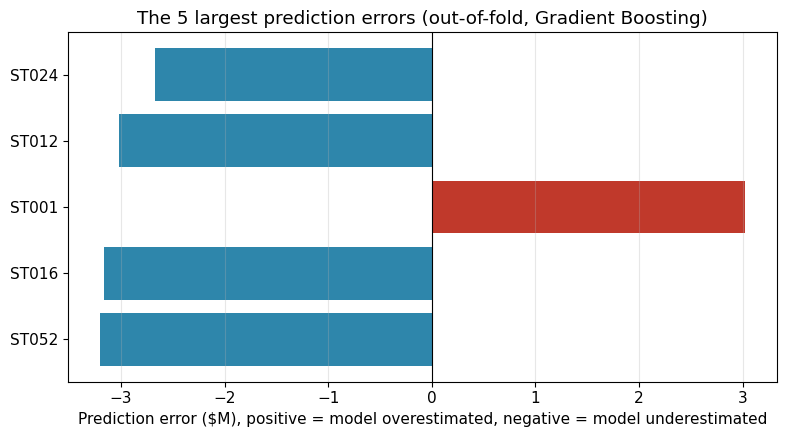

In [53]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = top5_errors['property_id']
colors_bar = ['#C0392B' if v > 0 else '#2E86AB' for v in top5_errors['signed_error']]
ax.barh(labels, top5_errors['signed_error'] / 1e6, color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Prediction error ($M), positive = model overestimated, negative = model underestimated')
ax.set_title('The 5 largest prediction errors (out-of-fold, Gradient Boosting)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**All five largest errors are Strathfield houses**, with no major errors from Surry Hills, Campbelltown, or units. This suggests that the model has more difficulty predicting prices at the **higher end of the Strathfield market**. Four of the five were **underestimated** and only one was **overestimated**, so this is not a one-directional bias, the model struggles with high-value Strathfield houses in both directions rather than consistently under- or over-pricing them.

* **ST052:** The model **underestimated** the price by **$3.20M (35.1%)**. Despite a large 696 sqm block and eight car spaces, the model predicted well below the actual $9.10M sale. Missing `floor_area_sqm` meant the model could not account for the size or condition of the dwelling.

* **ST016:** The model **underestimated** the **highest-priced property in the dataset** ($12.05M) by **$3.16M (26.2%)**. This property was already flagged as a suburb-wise IQR price outlier in Section 2.4, and it indicates that the model does not fully capture the premium associated with the very top end of the market.

* **ST001:** The model **overestimated** the price by **$3.02M (80.6%)**, the only overestimate among the five. Its five car spaces and large block pushed the prediction well above the actual $3.75M sale price, suggesting the available features do not reflect why this particular property sold relatively cheaply for its structural profile.

* **ST012:** The model **underestimated** the price by **$3.02M (32.5%)**. The property had six bedrooms and six bathrooms, but its missing floor area may have limited the model's ability to capture its overall size.

* **ST024:** The model **underestimated** the price by **$2.67M (24.7%)**. Its combination of many bedrooms, bathrooms, and car spaces with a smaller land size is less common in the training data.

The errors show that **land size and basic structural features are not enough to explain premium property prices**, and that the model's difficulty with Strathfield houses runs in both directions rather than a single systematic bias. Features such as floor area, property condition, age, renovation quality, and more detailed location information could improve predictions, particularly for high-value Strathfield properties.


## 4.3 Why were these properties difficult to predict?

In [54]:
print("Missing floor_area_sqm among the 5 largest errors:", top5_errors['floor_area_sqm'].isna().sum(), "/ 5")
print("\nAll 5 are Strathfield houses:", (top5_errors['suburb'] == 'Strathfield').all() and (top5_errors['property_type'] == 'House').all())
print("\nMean |error| for Strathfield houses vs. rest of dataset:")
fe['is_strath_house'] = (fe.suburb == 'Strathfield') & (fe.property_type == 'House')
print(fe.groupby('is_strath_house')['abs_error'].mean().round(0))
print("\nMean |error| by suburb:")
print(fe.groupby('suburb')['abs_error'].mean().round(0).reindex(SUBURBS))
print("\nMean % error by suburb:")
print(fe.groupby('suburb')['pct_error'].mean().round(1).reindex(SUBURBS))

Missing floor_area_sqm among the 5 largest errors: 5 / 5

All 5 are Strathfield houses: True

Mean |error| for Strathfield houses vs. rest of dataset:
is_strath_house
False     208462.0
True     1025953.0
Name: abs_error, dtype: float64

Mean |error| by suburb:
suburb
Surry Hills     338860.0
Strathfield     690043.0
Campbelltown     98775.0
Name: abs_error, dtype: float64

Mean % error by suburb:
suburb
Surry Hills     20.1
Strathfield     17.5
Campbelltown    10.8
Name: pct_error, dtype: float64


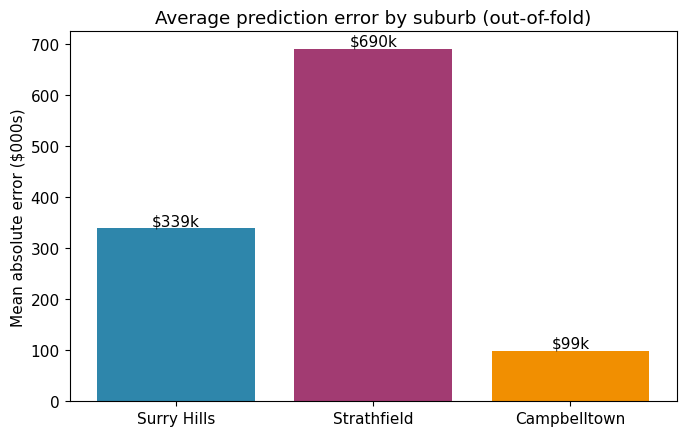

In [55]:
fig, ax = plt.subplots(figsize=(7, 4.5))
err_by_suburb = fe.groupby('suburb')['abs_error'].mean().reindex(SUBURBS) / 1e3
ax.bar(SUBURBS, err_by_suburb, color=[COLORS[s] for s in SUBURBS])
ax.set_ylabel('Mean absolute error ($000s)')
ax.set_title('Average prediction error by suburb (out-of-fold)')
for i, v in enumerate(err_by_suburb):
 ax.text(i, v, f'${v:,.0f}k', ha='center', va='bottom')
plt.tight_layout()
plt.show()

The error analysis shows three patterns.

1. **Strathfield houses account for all five largest errors.** They also have a higher mean absolute error than Surry Hills and Campbelltown, suggesting more variation in prices within this market.

2. **All five properties are missing `floor_area_sqm`.** The imputed values may not represent the actual size or quality of the dwelling. This makes it harder for the model to distinguish between older houses and larger or recently rebuilt properties.

3. **The errors occur in both directions.** Some properties are overestimated while others are underestimated. This suggests that the main issue is missing property information, such as floor area, condition, and build quality, rather than a consistent bias against Strathfield properties.


## 4.4 Model limitations and useful additional information

The error analysis suggests that the main limitations are related to the **available data rather than the model choice**.

* **Property condition and renovation status** were not collected. A four-bedroom house with a large block can have very different values depending on its condition.
* **Floor area** is missing for many properties and all five largest errors. Collecting this information could improve predictions, especially for houses.
* **Land characteristics**, such as shape, slope, and aspect, were not recorded but may affect property value.
* **Sale circumstances**, such as auctions or deceased estates, were not captured and may explain unusual sale prices.
* **Micro-location factors**, such as station distance and school catchments, were not captured beyond suburb level.

## 4.5 When predictions should be treated with caution

Predictions should be treated cautiously for **high-value or unusual properties**, particularly Strathfield houses. Extra caution is also needed when floor area is missing or bedroom and bathroom numbers are unusual for the land size. These properties may have factors not captured in the dataset.

## 4.6 Difficulty predicting Strathfield houses

Yes. **Strathfield houses appear more difficult to predict** than units and Campbelltown houses. Houses have greater variation in condition, construction, land use, and design, while units are generally more standardised. Improving the property data would likely be more useful than simply changing the algorithm.



# Part 5: Human Judgement, Machine Learning, and Large Language Models

To evaluate the predictive performance of the three approaches, ten properties were selected from the held-out test set that were not used during model training. Sale prices were estimated using the best-performing machine learning model from Part 3, ChatGPT using the same structured property information, and independent human estimates based on market knowledge developed during the project. The three sets of predictions were then compared with the actual sale prices.

## 5.1 Selecting ten held-out properties

The ten properties were deliberately selected to represent all three suburbs and a wide price range, from **\$375K** to **\$6.94M**. Rather than selecting properties randomly, the sample was chosen to test the three approaches across different segments of the market.


In [56]:
SELECTED_IDS = ['CB030', 'CB019', 'CB021', 'ST035', 'ST040', 'ST007', 'SH041', 'SH009', 'SH034', 'SH037']

test_ids = fe.loc[X_test.index, 'property_id']
mask5 = test_ids.isin(SELECTED_IDS)
X_part5 = X_test[mask5]
ids_part5 = test_ids[mask5]

# Check that all ten selected properties are from the held-out test set.
assert set(SELECTED_IDS).issubset(set(test_ids)), "A selected property is not in the held-out test set"
assert len(X_part5) == len(SELECTED_IDS), "Not all selected properties were found in the test split"
print(f"Verified: all {len(SELECTED_IDS)} selected properties are in the held-out test set (not seen during training).")

part5 = fe.set_index('property_id').loc[SELECTED_IDS].reset_index()
part5 = part5[['property_id', 'suburb', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces',
 'land_size_sqm', 'floor_area_sqm', 'sale_price']]
part5


Verified: all 10 selected properties are in the held-out test set (not seen during training).


,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,floor_area_sqm,sale_price
0,CB030,Campbelltown,Unit,2,1.0,1.0,NaN,106.0,445000
1,CB019,Campbelltown,House,3,2.0,1.0,248.1,NaN,960000
2,CB021,Campbelltown,House,7,4.0,4.0,470.0,NaN,1670000
3,ST035,Strathfield,Unit,1,1.0,1.0,NaN,76.0,600000
4,ST040,Strathfield,House,3,2.0,2.0,562.8,NaN,3150000
5,ST007,Strathfield,House,5,5.0,3.0,676.6,NaN,6936000
6,SH041,Surry Hills,Unit,1,1.0,NaN,NaN,20.0,375000
7,SH009,Surry Hills,Unit,1,1.0,NaN,NaN,65.0,920000
8,SH034,Surry Hills,Unit,2,1.0,1.0,NaN,111.0,1625000
9,SH037,Surry Hills,House,3,2.0,NaN,107.0,NaN,3300000


## 5.2 Approach 1 - Machine learning model (Gradient Boosting, from Part 3)

The Part 3 Gradient Boosting pipeline, fitted only on the training split, was used to predict these ten held-out properties, exactly as it would be used in production.

In [57]:
ml_log_pred = models['Gradient Boosting'].predict(X_part5)
ml_dollar_pred = np.exp(ml_log_pred)

ml_lookup = pd.Series(ml_dollar_pred, index=ids_part5.values)
part5['ml_pred'] = part5['property_id'].map(ml_lookup).round(0)
part5

,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,floor_area_sqm,sale_price,ml_pred
0,CB030,Campbelltown,Unit,2,1.0,1.0,NaN,106.0,445000,653528.0
1,CB019,Campbelltown,House,3,2.0,1.0,248.1,NaN,960000,963227.0
2,CB021,Campbelltown,House,7,4.0,4.0,470.0,NaN,1670000,1621352.0
3,ST035,Strathfield,Unit,1,1.0,1.0,NaN,76.0,600000,605900.0
4,ST040,Strathfield,House,3,2.0,2.0,562.8,NaN,3150000,3043423.0
5,ST007,Strathfield,House,5,5.0,3.0,676.6,NaN,6936000,5779606.0
6,SH041,Surry Hills,Unit,1,1.0,NaN,NaN,20.0,375000,451247.0
7,SH009,Surry Hills,Unit,1,1.0,NaN,NaN,65.0,920000,818727.0
8,SH034,Surry Hills,Unit,2,1.0,1.0,NaN,111.0,1625000,1326332.0
9,SH037,Surry Hills,House,3,2.0,NaN,107.0,NaN,3300000,2909449.0


## 5.3 Approach 2 - ChatGPT estimate

The same ten properties were provided to ChatGPT using the structured property information available for the comparison: suburb, property type, bedrooms, bathrooms, car spaces, land size, and floor area. The reference medians used in the reasoning were calculated from the training split only.

**Methodological caveat:** The LLM estimates were produced within the same broader working session used to develop this project. Because the notebook, dataset structure, and related analysis were part of that working context, I cannot treat this as a fully blind benchmark against a fresh language model with no prior exposure to the project. For that reason, the LLM results are presented as an **illustrative comparison**, not as evidence that an LLM would achieve the same performance in a strictly controlled unseen-data experiment.

A stronger experiment would use a fresh LLM session supplied only with the ten held-out feature rows and no notebook outputs, model results, or actual sale prices. The comparison below is therefore interpreted cautiously.

In [58]:
# Reference medians are calculated from the training split only.
train_ids = fe.loc[X_train.index, 'property_id']
train_ref = fe[fe.property_id.isin(train_ids)]
ref_table = train_ref.groupby(['suburb', 'property_type', 'bedrooms'])['sale_price'].agg(['median', 'count'])
ref_table.head(10)

median  count
suburb       property_type bedrooms                  
Campbelltown House         2          870000.0      1
                           3          950000.0     11
                           4         1071000.0     14
                           5         1195000.0      1
                           6         1197500.0      2
             Semi/Terrace  3          890000.0      1
             Townhouse     2          726500.0      2
             Unit          1          430000.0      1
                           2          584000.0     11
                           3          660000.0      3

**Reasoning used for each property** (structural features + the training-only reference medians above + general Sydney market knowledge):

| Property | Features | Reasoning | LLM estimate |
|---|---|---|---|
| **CB030** | Campbelltown Unit, 2 bed, floor 106 sqm | Training median for CB 2-bed units ≈ \$584K; 106 sqm is larger than a typical 2-bed unit (~70-90 sqm), suggesting a premium over the median | **\$620,000** |
| **CB019** | Campbelltown House, 3 bed, land 248 sqm | Training median for CB 3-bed houses ≈ \$950K; 248 sqm is a small block for a house in this suburb (typical is 600-700 sqm), suggesting a discount for limited land | **\$820,000** |
| **CB021** | Campbelltown House, 7 bed, land 470 sqm | No direct 7-bed comparable in training data; extrapolating from the 6-bed median (\$1.20M) and the modest land size for that many bedrooms | **\$1,300,000** |
| **ST035** | Strathfield Unit, 1 bed, floor 76 sqm | Training median for ST 1-bed units ≈ \$540K; 76 sqm is above-average size for a 1-bed, small upward adjustment | **\$580,000** |
| **ST040** | Strathfield House, 3 bed, land 563 sqm | Training median for ST 3-bed houses ≈ \$3.60M; land size is below the typical range for this group, suggesting a discount | **\$3,300,000** |
| **ST007** | Strathfield House, 5 bed, 5 bath, land 677 sqm | Training median for ST 5-bed houses ≈ \$5.00M; unusually high bathroom count (5) signals a premium/luxury build, adjusted upward | **\$6,000,000** |
| **SH041** | Surry Hills Unit, 1 bed, floor 20 sqm | Training median for SH 1-bed units ≈ \$775K, but that figure includes much larger 1-beds; 20 sqm is a genuine micro-studio, well below typical size - large downward adjustment | **\$420,000** |
| **SH009** | Surry Hills Unit, 1 bed, floor 65 sqm | 65 sqm is a generously sized 1-bed relative to the training median's typical size - upward adjustment | **\$850,000** |
| **SH034** | Surry Hills Unit, 2 bed, floor 111 sqm | Training median for SH 2-bed units ≈ \$1.40M; 111 sqm is a large 2-bed - upward adjustment | **\$1,550,000** |
| **SH037** | Surry Hills House, 3 bed, land 107 sqm | Training median for SH 3-bed houses ≈ \$2.53M; small terrace-style block is typical for Surry Hills, but terrace houses often carry a heritage/character premium | **\$2,700,000** |


The values in the table are the same values used in the code below (`llm_estimates`). Because this was not a fully blind LLM experiment, they are interpreted only as an illustrative comparison.


In [59]:
# ChatGPT estimates used in the Part 5 comparison.
# The comparison is treated as illustrative rather than fully blind.
llm_estimates = {
 'CB030': 620_000, # Campbelltown Unit, 2 bed, floor 106 sqm
 'CB019': 820_000, # Campbelltown House, 3 bed, land 248 sqm
 'CB021': 1_300_000, # Campbelltown House, 7 bed, land 470 sqm
 'ST035': 580_000, # Strathfield Unit, 1 bed, floor 76 sqm
 'ST040': 3_300_000, # Strathfield House, 3 bed, land 563 sqm
 'ST007': 6_000_000, # Strathfield House, 5 bed / 5 bath, land 677 sqm
 'SH041': 420_000, # Surry Hills Unit, 1 bed, floor 20 sqm (micro-studio)
 'SH009': 850_000, # Surry Hills Unit, 1 bed, floor 65 sqm
 'SH034': 1_550_000, # Surry Hills Unit, 2 bed, floor 111 sqm
 'SH037': 2_700_000, # Surry Hills House, 3 bed, land 107 sqm
}
part5['llm_pred'] = part5['property_id'].map(llm_estimates)
part5


,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,floor_area_sqm,sale_price,ml_pred,llm_pred
0,CB030,Campbelltown,Unit,2,1.0,1.0,NaN,106.0,445000,653528.0,620000
1,CB019,Campbelltown,House,3,2.0,1.0,248.1,NaN,960000,963227.0,820000
2,CB021,Campbelltown,House,7,4.0,4.0,470.0,NaN,1670000,1621352.0,1300000
3,ST035,Strathfield,Unit,1,1.0,1.0,NaN,76.0,600000,605900.0,580000
4,ST040,Strathfield,House,3,2.0,2.0,562.8,NaN,3150000,3043423.0,3300000
5,ST007,Strathfield,House,5,5.0,3.0,676.6,NaN,6936000,5779606.0,6000000
6,SH041,Surry Hills,Unit,1,1.0,NaN,NaN,20.0,375000,451247.0,420000
7,SH009,Surry Hills,Unit,1,1.0,NaN,NaN,65.0,920000,818727.0,850000
8,SH034,Surry Hills,Unit,2,1.0,1.0,NaN,111.0,1625000,1326332.0,1550000
9,SH037,Surry Hills,House,3,2.0,NaN,107.0,NaN,3300000,2909449.0,2700000


## 5.4 Approach 3 - My own estimates

For the third approach, the prices of the same ten held-out properties were estimated using their property characteristics and the market patterns identified during the exploratory analysis. Factors considered included suburb, property type, bedrooms, bathrooms, car spaces and available land or floor area. The reasoning for each estimate is provided below to show how these property characteristics influenced my judgement.

**Reasoning for the Human Estimates**

The human judgement approach considered suburb, property type, bedrooms, bathrooms, car spaces, land size, and floor area where available. Training-set price patterns were used as general reference points, followed by subjective upward or downward adjustments according to each property's characteristics. The table below summarises the reasoning behind each estimate.


| Property | Information considered | Human estimate |
| --- | --- | ---: |
| **CB030** | Campbelltown unit; 2 bedrooms, 1 bathroom, 1 car space; relatively large 106 sqm floor area suggested a value above a smaller typical unit | **\$650,000** |
| **CB019** | Campbelltown house; 3 bedrooms, 2 bathrooms and 1 car space; relatively small 248 sqm land size led to a downward adjustment | **\$780,000** |
| **CB021** | Campbelltown house; unusual 7-bedroom configuration, 4 bathrooms and 4 car spaces; 470 sqm land; limited comparable properties made it difficult to estimate | **\$1,450,000** |
| **ST035** | Strathfield unit; 1 bedroom, 1 bathroom and 1 car space; 76 sqm floor area was relatively generous for a one-bedroom unit | **\$600,000** |
| **ST040** | Strathfield house; 3 bedrooms, 2 bathrooms and 2 car spaces; 563 sqm land was slightly smaller than some comparable houses observed in the dataset | **\$3,400,000** |
| **ST007** | Strathfield house; 5 bedrooms, 5 bathrooms, 3 car spaces and 677 sqm land; the overall size and high number of bathrooms suggested a higher-end property | **\$6,200,000** |
| **SH041** | Surry Hills unit; 1 bedroom and 1 bathroom; very small 20 sqm floor area and no recorded parking led to a substantial downward adjustment | **\$350,000** |
| **SH009** | Surry Hills unit; 1 bedroom and 1 bathroom; 65 sqm floor area was reasonable, but no recorded car space led to a more conservative estimate | **\$760,000** |
| **SH034** | Surry Hills unit; 2 bedrooms, 1 bathroom, 1 car space and relatively large 111 sqm floor area suggested a higher value within this property type | **\$1,600,000** |
| **SH037** | Surry Hills house; 3 bedrooms and 2 bathrooms on a small 107 sqm block; small land size was balanced against the relatively high value of houses in Surry Hills | **\$2,900,000** |

This approach represents informed but subjective judgement rather than a formal valuation model. It provides a useful comparison with the machine learning and ChatGPT estimates, while also showing that human judgement can consider individual property characteristics but may be less consistent than a trained model.


In [60]:
human_estimates = {
 'CB030': 650_000, # Campbelltown Unit, 2 bed, floor 106 sqm
 'CB019': 780_000, # Campbelltown House, 3 bed, land 248 sqm
 'CB021': 1_450_000, # Campbelltown House, 7 bed, land 470 sqm
 'ST035': 600_000, # Strathfield Unit, 1 bed, floor 76 sqm
 'ST040': 3_400_000, # Strathfield House, 3 bed, land 563 sqm
 'ST007': 6_200_000, # Strathfield House, 5 bed / 5 bath, land 677 sqm
 'SH041': 350_000, # Surry Hills Unit, 1 bed, floor 20 sqm (micro-studio)
 'SH009': 760_000, # Surry Hills Unit, 1 bed, floor 65 sqm
 'SH034': 1_600_000, # Surry Hills Unit, 2 bed, floor 111 sqm
 'SH037': 2_900_000, # Surry Hills House, 3 bed, land 107 sqm
}
part5['human_pred'] = part5['property_id'].map(human_estimates)
part5

,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,floor_area_sqm,sale_price,ml_pred,llm_pred,human_pred
0,CB030,Campbelltown,Unit,2,1.0,1.0,NaN,106.0,445000,653528.0,620000,650000
1,CB019,Campbelltown,House,3,2.0,1.0,248.1,NaN,960000,963227.0,820000,780000
2,CB021,Campbelltown,House,7,4.0,4.0,470.0,NaN,1670000,1621352.0,1300000,1450000
3,ST035,Strathfield,Unit,1,1.0,1.0,NaN,76.0,600000,605900.0,580000,600000
4,ST040,Strathfield,House,3,2.0,2.0,562.8,NaN,3150000,3043423.0,3300000,3400000
5,ST007,Strathfield,House,5,5.0,3.0,676.6,NaN,6936000,5779606.0,6000000,6200000
6,SH041,Surry Hills,Unit,1,1.0,NaN,NaN,20.0,375000,451247.0,420000,350000
7,SH009,Surry Hills,Unit,1,1.0,NaN,NaN,65.0,920000,818727.0,850000,760000
8,SH034,Surry Hills,Unit,2,1.0,1.0,NaN,111.0,1625000,1326332.0,1550000,1600000
9,SH037,Surry Hills,House,3,2.0,NaN,107.0,NaN,3300000,2909449.0,2700000,2900000


## 5.5 Comparing all three approaches against the actual sale price

The recorded ML, LLM, and human judgement estimates are compared below with the actual sale prices for the same ten held-out properties.


In [61]:
for col, label in [('ml_pred', 'ML (Gradient Boosting)'), ('llm_pred', 'LLM (ChatGPT)'), ('human_pred', 'Human judgement')]:
 part5[f'{col}_abs_err'] = np.abs(part5['sale_price'] - part5[col])
 part5[f'{col}_pct_err'] = part5[f'{col}_abs_err'] / part5['sale_price'] * 100

display_cols = ['property_id', 'suburb', 'sale_price', 'ml_pred', 'llm_pred', 'human_pred',
 'ml_pred_pct_err', 'llm_pred_pct_err', 'human_pred_pct_err']
part5[display_cols].round(1)

,property_id,suburb,sale_price,ml_pred,llm_pred,human_pred,ml_pred_pct_err,llm_pred_pct_err,human_pred_pct_err
0,CB030,Campbelltown,445000,653528.0,620000,650000,46.9,39.3,46.1
1,CB019,Campbelltown,960000,963227.0,820000,780000,0.3,14.6,18.8
2,CB021,Campbelltown,1670000,1621352.0,1300000,1450000,2.9,22.2,13.2
3,ST035,Strathfield,600000,605900.0,580000,600000,1.0,3.3,0.0
4,ST040,Strathfield,3150000,3043423.0,3300000,3400000,3.4,4.8,7.9
5,ST007,Strathfield,6936000,5779606.0,6000000,6200000,16.7,13.5,10.6
6,SH041,Surry Hills,375000,451247.0,420000,350000,20.3,12.0,6.7
7,SH009,Surry Hills,920000,818727.0,850000,760000,11.0,7.6,17.4
8,SH034,Surry Hills,1625000,1326332.0,1550000,1600000,18.4,4.6,1.5
9,SH037,Surry Hills,3300000,2909449.0,2700000,2900000,11.8,18.2,12.1


In [62]:
summary = pd.DataFrame({
 'ML (Gradient Boosting)': {
 'MAE ($)': part5['ml_pred_abs_err'].mean(),
 'MAPE (%)': part5['ml_pred_pct_err'].mean(),
 },
 'LLM (ChatGPT)': {
 'MAE ($)': part5['llm_pred_abs_err'].mean(),
 'MAPE (%)': part5['llm_pred_pct_err'].mean(),
 },
 'Human judgement': {
 'MAE ($)': part5['human_pred_abs_err'].mean(),
 'MAPE (%)': part5['human_pred_pct_err'].mean(),
 },
}).T.round(1)
summary

,MAE ($),MAPE (%)
ML (Gradient Boosting),239601.3,13.3
LLM (ChatGPT),258100.0,14.0
Human judgement,220100.0,13.4


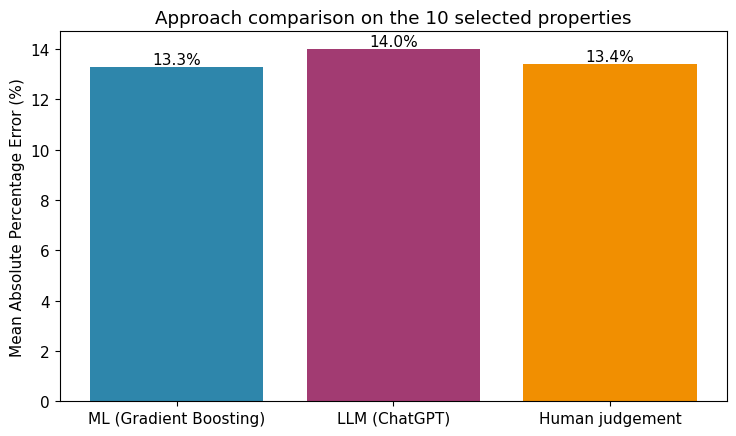

In [63]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
approaches = summary.index.tolist()
mape_vals = summary['MAPE (%)'].values
bar_colors = ['#2E86AB', '#A23B72', '#F18F01']
ax.bar(approaches, mape_vals, color=bar_colors)
ax.set_ylabel('Mean Absolute Percentage Error (%)')
ax.set_title('Approach comparison on the 10 selected properties')
for i, v in enumerate(mape_vals):
 ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 5.6 Discussion

The three approaches produced similar results on the ten-property sample. Gradient Boosting had the lowest **MAPE (13.3%)**, while human judgement had the lowest **MAE (≈ \$220K)** and a very close MAPE (13.4%). The LLM was slightly higher on both (MAPE 14.0%, MAE ≈ \$258K). With only ten properties, these differences may reflect sampling variation, so the results are treated as exploratory rather than a reliable ranking. The LLM results also require caution because the estimates were not generated under blind conditions (Section 5.3).

All three approaches overestimated CB030, possibly because its relatively large 106 sqm floor area contributed to estimates above its actual sale price of \$445K. They also underestimated **ST007**, a \$6.94M Strathfield property, with the human estimate being closest after considering its high-end and prestige characteristics.

The results also show that human judgement was not always more accurate. For CB019, the human estimate was below the actual sale price, showing that subjective adjustments can sometimes be less reliable than comparable-sales information.

Overall, ML provided consistency, scalability, and the lowest MAPE on this sample, while human judgement may add contextual value but remains subjective, particularly for unusual or high-value properties. The LLM's performance is harder to assess because the estimates were not produced under blind conditions. Given the small sample, the findings should be considered exploratory rather than conclusive.


# Part 6: Final Deployment and Reflection

A simple web application was built with **Streamlit** so that a non-technical user (e.g. a real-estate agent or a vendor) can enter a property's details and receive an instant, model-generated price estimate, without touching this notebook or any code.

## 6.1 How I developed the application

**Framework:** Streamlit was selected because it allows a Python model to be presented as a simple web application without requiring extensive front-end development. This suited the scope of the project and made it possible to build a simple decision-support prototype.

**Architecture:** The final Gradient Boosting pipeline was retrained using all 179 properties and saved with `joblib`, together with the required feature names and suburb/property-type median prices. The `HousingFeatureEngineer` transformer is defined once in `housing_transformer.py` (Section 3.1a) and imported by both the training pipeline and `app.py`, so the two can never drift apart. The `app.py` file loads these components and provides an input form for the property details, including options to mark land size or floor area as unknown. The inputs are then passed through the same preprocessing and modelling pipeline used in Part 3 to generate a predicted sale price.

The application also includes a **caution message and an "About this tool" section** explaining the model's limitations. This makes clear that the output is an estimate and not a certified property valuation.

**Deployment:** The application is deployed publicly on Streamlit Community Cloud at **https://sydney-housing-price-estimator-bry2nekjdhy9gnxtiodyji.streamlit.app** .The screenshots below were captured from the live deployed instance.


## 6.2 Save the trained pipeline for the app

For deployment, the final model is retrained on all 179 properties by combining the training and holdout data. Since no held-out evaluation is performed at this stage, the `HousingFeatureEngineer` step is refit on all 179 rows, allowing the production model to use imputation medians for land size, floor area, and bathrooms based on the full dataset.

All evaluation results in Parts 3-5, including cross-validation, the holdout check, and the Part 5 comparison, were completed before this final refit. Therefore, the reported evaluation results do not use information from the final full-dataset fit.

In [64]:
import joblib, os

OUT_DIR = os.getcwd() # save directly in this notebook's folder, next to app.py

# After evaluation is finished, retrain the selected model on all 179 properties
# for the deployed app. This does not affect the earlier holdout results.
#
# Clone the tuned Gradient Boosting pipeline used in Part 3.
final_pipeline = clone(models['Gradient Boosting'])
final_pipeline.fit(X, y)

# Use the tuned Gradient Boosting settings for the quantile models below.
_tuned_gbm_params = final_pipeline.named_steps['model'].get_params()
_tuned_kwargs = {k: _tuned_gbm_params[k] for k in ('n_estimators', 'max_depth', 'learning_rate', 'random_state')}
print("Deployment model hyperparameters (from Section 3.2b's GridSearchCV):", _tuned_kwargs)

# Train two quantile models to give an approximate 80% prediction range.
# This range is useful for the app, but it should not be treated as a guaranteed
# confidence interval.
lower_pipeline = Pipeline([
 ('prep', clone(preprocess)),
 ('model', GradientBoostingRegressor(loss='quantile', alpha=0.1, **_tuned_kwargs)),
])
upper_pipeline = Pipeline([
 ('prep', clone(preprocess)),
 ('model', GradientBoostingRegressor(loss='quantile', alpha=0.9, **_tuned_kwargs)),
])
lower_pipeline.fit(X, y)
upper_pipeline.fit(X, y)

joblib.dump(final_pipeline, os.path.join(OUT_DIR, 'sydney_price_model.joblib'))
joblib.dump(lower_pipeline, os.path.join(OUT_DIR, 'sydney_price_model_p10.joblib'))
joblib.dump(upper_pipeline, os.path.join(OUT_DIR, 'sydney_price_model_p90.joblib'))
joblib.dump(RAW_INPUT_COLS, os.path.join(OUT_DIR, 'raw_input_cols.joblib'))

ref_medians = fe.groupby(['suburb', 'property_type'])['sale_price'].median()
joblib.dump(ref_medians, os.path.join(OUT_DIR, 'ref_medians.joblib'))

print(f"Saved 5 model artefacts to the notebook's folder (trained on {len(fe)} properties).")
print("Files: sydney_price_model.joblib, sydney_price_model_p10.joblib, sydney_price_model_p90.joblib,")
print(" raw_input_cols.joblib, ref_medians.joblib")
print("\nOnly relative filenames are printed above, not the full local file path.")

# Keep housing_transformer.py with app.py so the saved model loads correctly.
assert os.path.exists(os.path.join(OUT_DIR, 'housing_transformer.py')), (
 "housing_transformer.py not found next to the .joblib files -- re-run the "
 "Section 3.1a cell first, then re-run this cell. app.py will fail to load "
 "the model without it."
)
print("Confirmed: housing_transformer.py is present alongside the model artefacts.")

Deployment model hyperparameters (from Section 3.2b's GridSearchCV): {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'random_state': 42}
Saved 5 model artefacts to the notebook's folder (trained on 179 properties).
Files: sydney_price_model.joblib, sydney_price_model_p10.joblib, sydney_price_model_p90.joblib,
 raw_input_cols.joblib, ref_medians.joblib

Only relative filenames are printed above, not the full local file path.
Confirmed: housing_transformer.py is present alongside the model artefacts.


**Prediction intervals.** The original app returned a single point estimate, which overstates the precision a model trained on 179 properties can actually support. The two quantile-loss models above give a simple empirical 10th-90th percentile band around the point estimate. This is **not** a formal, coverage-guaranteed confidence interval -- it is two independently fit conditional-quantile models, and quantile crossing is possible (handled defensively in `app.py` below). It is still more informative than showing only a single point estimate, and is now reflected in the updated app.

## 6.3 The application code (`app.py`)

In [65]:
%%writefile app.py
import os

import joblib
import numpy as np
import pandas as pd
import streamlit as st

from housing_transformer import HousingFeatureEngineer  # needed when loading the saved model


st.set_page_config(
    page_title="Sydney Housing Price Estimator",
    page_icon="🏠",
    layout="centered",
)

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
model = joblib.load(os.path.join(BASE_DIR, "sydney_price_model.joblib"))
model_p10 = joblib.load(os.path.join(BASE_DIR, "sydney_price_model_p10.joblib"))
model_p90 = joblib.load(os.path.join(BASE_DIR, "sydney_price_model_p90.joblib"))
RAW_INPUT_COLS = joblib.load(os.path.join(BASE_DIR, "raw_input_cols.joblib"))
ref_medians = joblib.load(os.path.join(BASE_DIR, "ref_medians.joblib"))

st.markdown(
    """
    <style>
    .main { background-color: #FAFBFC; }
    h1 { color: #1B2A4A; }
    .stButton>button {
        background-color: #2E86AB;
        color: white;
        font-weight: 600;
        border-radius: 6px;
        padding: 0.6rem 1.2rem;
        border: none;
    }
    .result-box {
        background-color: #EAF2F8;
        border-left: 6px solid #2E86AB;
        padding: 1.2rem 1.5rem;
        border-radius: 8px;
        margin-top: 1rem;
    }
    </style>
    """,
    unsafe_allow_html=True,
)

st.title("🏠 Sydney Housing Price Estimator")
st.caption(
    "A decision-support prototype trained on 179 sold properties across "
    "Surry Hills, Strathfield, and Campbelltown. Enter a property's details "
    "to get an indicative sale price and prediction range."
)
st.divider()

col1, col2 = st.columns(2)

with col1:
    suburb = st.selectbox(
        "Suburb",
        ["Surry Hills", "Strathfield", "Campbelltown"],
    )
    property_type = st.selectbox(
        "Property type",
        ["House", "Unit", "Townhouse", "Semi/Terrace"],
    )
    bedrooms = st.number_input(
        "Bedrooms", min_value=0, max_value=10, value=3, step=1
    )
    bathrooms = st.number_input(
        "Bathrooms", min_value=0, max_value=10, value=2, step=1
    )
    car_spaces = st.number_input(
        "Car spaces", min_value=0, max_value=10, value=1, step=1
    )

with col2:
    has_land_size = st.checkbox(
        "Land size known?",
        value=(property_type == "House"),
        key=f"land_known_{property_type}",
    )
    land_size = st.number_input(
        "Land size (sqm)",
        min_value=0.0,
        max_value=3000.0,
        value=450.0,
        step=10.0,
        disabled=not has_land_size,
    )

    has_floor_area = st.checkbox(
        "Floor area known?",
        value=(property_type != "House"),
        key=f"floor_known_{property_type}",
    )
    floor_area = st.number_input(
        "Floor area (sqm)",
        min_value=0.0,
        max_value=1000.0,
        value=90.0,
        step=5.0,
        disabled=not has_floor_area,
    )

    sale_quarter = st.selectbox(
        "Expected sale quarter",
        [1, 2, 3, 4],
        index=2,
    )

st.divider()

if st.button("Estimate sale price", use_container_width=True):
    row = {
        "suburb": suburb,
        "property_type": property_type,
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "car_spaces": car_spaces,
        "land_size_sqm": land_size if has_land_size else np.nan,
        "floor_area_sqm": floor_area if has_floor_area else np.nan,
        "sale_quarter": sale_quarter,
    }

    X_input = pd.DataFrame([row])[RAW_INPUT_COLS]

    log_pred = model.predict(X_input)[0]
    pred_price = float(np.exp(log_pred))

    log_pred_low = model_p10.predict(X_input)[0]
    log_pred_high = model_p90.predict(X_input)[0]
    pred_low = float(np.exp(log_pred_low))
    pred_high = float(np.exp(log_pred_high))
    pred_low, pred_high = min(pred_low, pred_high), max(pred_low, pred_high)

    st.markdown(
        f"""
        <div class="result-box">
            <div style="font-size:0.95rem; color:#555;">
                Estimated sale price
            </div>
            <div style="font-size:2.2rem; font-weight:700; color:#1B2A4A;">
                ${pred_price:,.0f}
            </div>
            <div style="font-size:0.9rem; color:#555; margin-top:0.4rem;">
                Indicative prediction range (10th-90th percentile):
                ${pred_low:,.0f} &ndash; ${pred_high:,.0f}
            </div>
        </div>
        """,
        unsafe_allow_html=True,
    )

    try:
        typical = ref_medians.loc[(suburb, property_type)]
        st.caption(
            f"For comparison, the median sale price for {property_type}s "
            f"in {suburb} in the training data was ${typical:,.0f}."
        )
    except KeyError:
        st.caption(
            f"No comparable {property_type} sales for {suburb} were available "
            "in the training data, so this estimate should be treated with "
            "extra caution."
        )

    st.warning(
        "⚠️ This is a prototype estimate from a model trained on only 179 "
        "sold properties. It does not account for property condition, "
        "renovations, aspect, views, or other unique features, and should "
        "not replace a professional valuation."
    )

st.divider()

with st.expander("About this tool"):
    st.write(
        """
        This app uses the Gradient Boosting model developed in this project.

        **Known limitations:**
        - The dataset does not include property condition, renovation status or age.
        - Land size and floor area were missing for many properties and were imputed.
        - The data covers roughly 11 months, so longer-term market changes are not represented.
        - The prediction range is an estimate from two quantile models, not a guaranteed confidence interval.
        """
    )


Overwriting app.py


### `requirements.txt` (for local deployment)


**Reproducibility note -- updated after a real deployment failure.** An earlier version of this cell hand-pinned `pandas==2.2.2` and `scikit-learn==1.5.2` as "reasonable defaults" without verifying them against the actual training environment. When deployed, this caused the live app to crash: the saved `.joblib` files had actually been pickled with `scikit-learn==1.9.0` and a pandas 3.x string dtype that requires `pyarrow`, which the guessed pins did not include. Unpickling with the wrong pandas raised `TypeError: StringDtype.__init__() takes from 1 to 2 positional arguments but 3 were given`, and installing a newer pandas without also installing `pyarrow` then raised `ModuleNotFoundError: No module named 'pyarrow'`.

The lesson: **never hand-guess dependency pins for a project that pickles fitted objects.** The cell below fixes this permanently by detecting the versions of the packages actually imported in *this* kernel at the time it runs, via `importlib.metadata`, and writing exactly those into `requirements.txt` -- so `requirements.txt` can never silently drift from the environment that produced the `.joblib` files, no matter which machine or kernel this notebook is later run in.

In [66]:
import importlib.metadata as _im

# Save the package versions from the current environment so the app can be
# installed with the same versions used here.
_pkgs = ["streamlit", "pandas", "numpy", "scikit-learn", "joblib", "pyarrow", "openpyxl"]
_versions = {}
for _pkg in _pkgs:
    try:
        _versions[_pkg] = _im.version(_pkg)
    except _im.PackageNotFoundError:
        _versions[_pkg] = None

_missing = [p for p, v in _versions.items() if v is None]
if _missing:
    print(f"WARNING: these packages are not installed in this kernel and will be "
          f"OMITTED from requirements.txt -- install them here first if app.py "
          f"needs them: {_missing}")

_lines = [f"{pkg}=={ver}" for pkg, ver in _versions.items() if ver is not None]
with open("requirements.txt", "w") as f:
    f.write("\n".join(_lines) + "\n")

print("requirements.txt written from the live environment:")
print("\n".join(_lines))

requirements.txt written from the live environment:
streamlit==1.62.0
pandas==3.0.3
numpy==2.4.6
scikit-learn==1.9.0
joblib==1.5.3
pyarrow==25.0.1
openpyxl==3.1.5


## 6.4 Running the application

The app is deployed at **[https://sydney-housing-price-estimator-bry2nekjdhy9gnxtiodyji.streamlit.app/](https://sydney-housing-price-estimator-bry2nekjdhy9gnxtiodyji.streamlit.app/)** and requires no setup. Enter the property details and click **Estimate sale price** to get a point estimate, an indicative 10th-90th percentile range, a suburb-median comparison, and a limitations warning.

The project files are available in the **[GitHub repository](https://github.com/Jahan-Geo/sydney-housing-price-estimator)**. To run the application locally, download or clone the repository, run `pip install -r requirements.txt`, then run `streamlit run app.py` (see Section 6.3 for exact versions). The `housing_transformer.py` file must be in the same folder as `app.py`.

### Screenshot 1 - The application on load

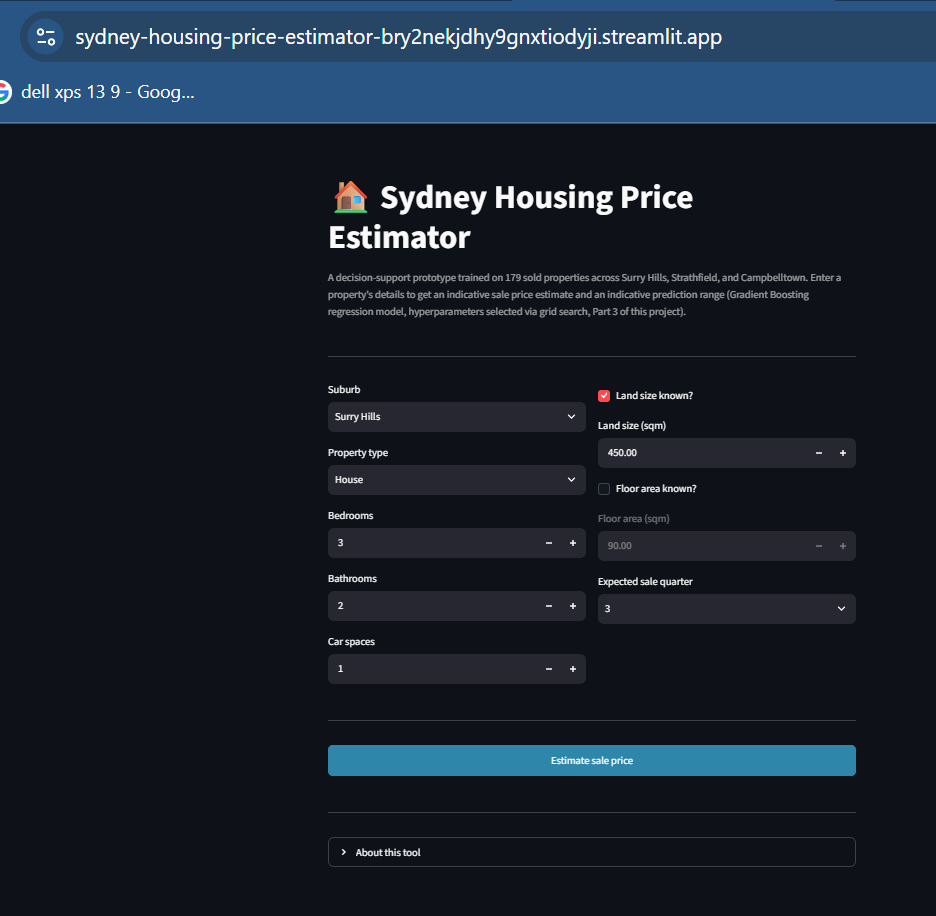

In [67]:
from IPython.display import Image, display
import os

_fname = "Screenshot-1.png"
if os.path.exists(_fname):
 display(Image(filename=_fname, width=500))
else:
 print(f"[{_fname} not found in this environment -- displays automatically when this "
 f"notebook is run from the submission folder, which includes the screenshot files.]")


### Screenshot 2 - A property's details entered (4-bed, 3-bath Strathfield house, 650 sqm land)

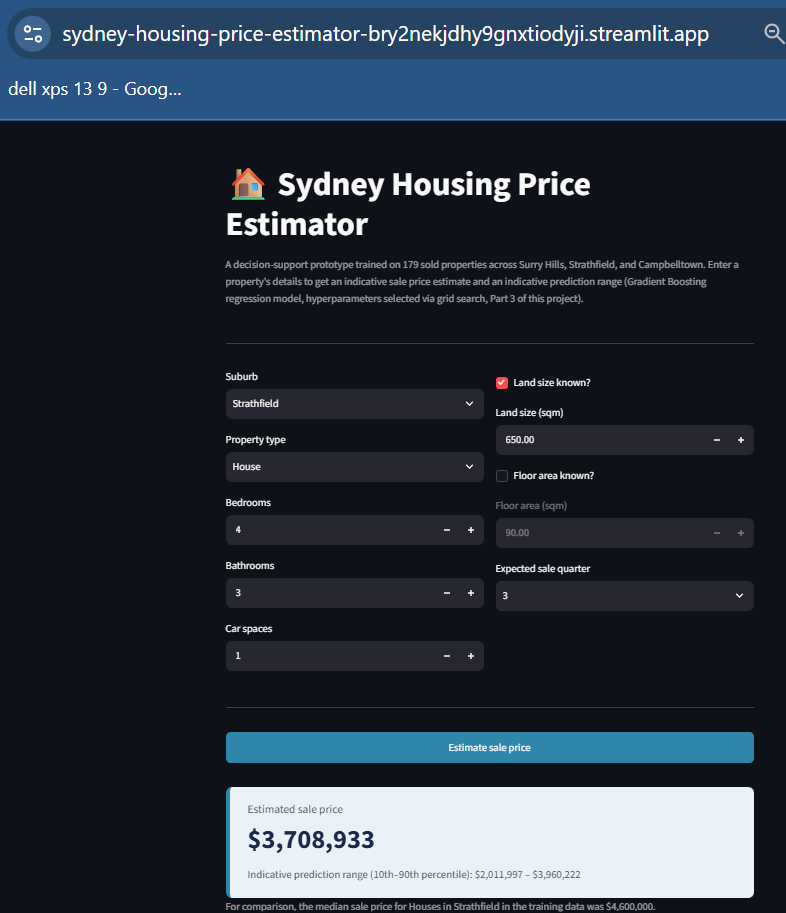

In [68]:
from IPython.display import Image, display
import os

_fname = "Screenshot-2.png"
if os.path.exists(_fname):
 display(Image(filename=_fname, width=500))
else:
 print(f"[{_fname} not found in this environment -- displays automatically when this "
 f"notebook is run from the submission folder, which includes the screenshot files.]")


### Screenshot 3 - Predicted price returned, with a suburb-median comparison and caution banner

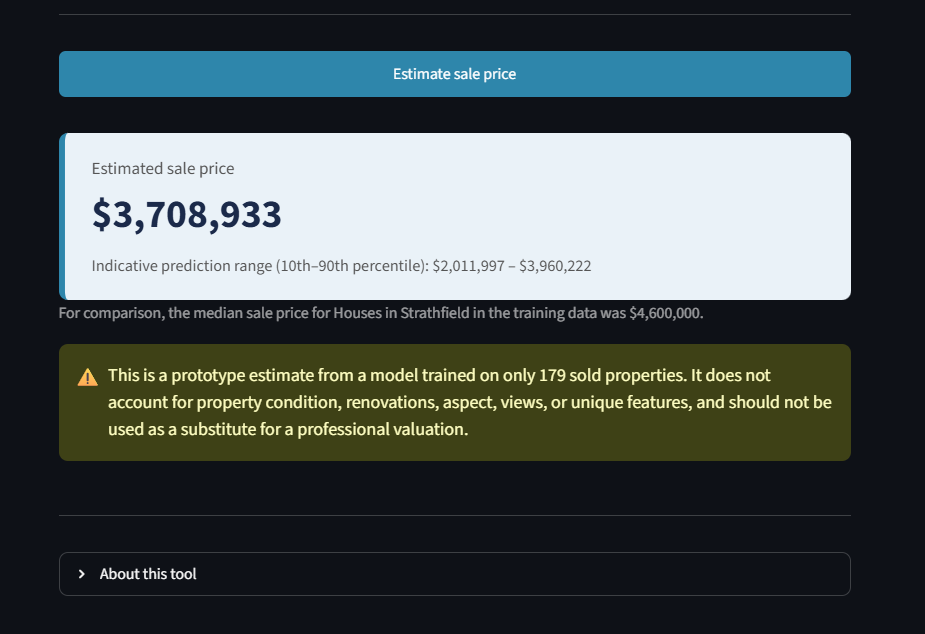

In [69]:
from IPython.display import Image, display
import os

_fname = "Screenshot-3.png"
if os.path.exists(_fname):
 display(Image(filename=_fname, width=500))
else:
 print(f"[{_fname} not found in this environment -- displays automatically when this "
 f"notebook is run from the submission folder, which includes the screenshot files.]")


For example, for a Strathfield house with 4 bedrooms, 3 bathrooms, 1 car space, 650 sqm of land, and an expected sale quarter of 3, the app returned an estimated price of **\$3,708,933**, with an indicative prediction range of **\$2,011,997** to **\$3,960,222**. This was compared with the training-data median of **\$4,600,000 for Strathfield houses**. The app also warns users that the estimate is based on only 179 sold properties and does not account for property condition, renovations, aspect, views, or other unique features. This is consistent with the Part 4 findings, where Strathfield houses produced some of the largest prediction errors because important property information was missing or unavailable.


## 6.5 Final reflection

### What I learned

One of the main lessons from the project was the importance of data quality. Missing information such as floor area, property condition and renovation status made unusual and expensive properties harder to predict.

I also learned that model accuracy should not be considered on its own. Gradient Boosting performed best overall, but I still needed to check overfitting, holdout performance and the largest prediction errors.

### Challenges

The main challenges were collecting reliable property data, dealing with missing and unusual values, and training models with only 179 usable properties. I also had to make sure the Streamlit app used the same preprocessing as the trained model.

### Model performance and deployment

Gradient Boosting was selected because it gave the best overall performance. Ridge Regression was easier to interpret but was less accurate. The app therefore uses Gradient Boosting and presents the result as an estimated price rather than a professional valuation.

### Ethical considerations

The model may reflect bias in the collected data. Prediction errors were much higher for Strathfield than Campbelltown, showing that accuracy is not equal across suburbs. Properties without publicly available sale information may also be under-represented.

Another limitation is that `source_url`, `listing_description` and `year_built` were missing for all properties. Keeping source URLs in future data collection would make the dataset easier to verify.

Users should not rely on one predicted price alone. The app includes a prediction range and limitations to show some of this uncertainty. It should be used as decision support, not as a replacement for professional valuation.

### Future improvements

With more time, I would collect more properties across multiple years and add information such as floor area, property condition, renovation status and more detailed location data. Listing descriptions could also be useful. The app could later be improved by monitoring its predictions as more data becomes available.


## GenAI Acknowledgement

ChatGPT was used for planning, checking clarity, and improving grammar and wording. Suggestions were checked against the notebook results and task requirements, then adjusted to match the understanding developed through the project. The modelling decisions, results and conclusions in this report are based on the project work.

## References

realestate.com.au. (2026). *Sold property listings, Surry Hills, Strathfield, Campbelltown, NSW* [Data source]. https://www.realestate.com.au

Streamlit Inc. (2026). *Streamlit documentation*. https://docs.streamlit.io
